# Part 2 - Exploratory Data Analysis (EDA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

import sys
from pathlib import Path

SRC_PATH = Path.cwd().parent / "src"
sys.path.append(str(SRC_PATH))

## 1. Data Loading

In [2]:
conn = sqlite3.connect("../data/reviews_analysis.db")

hotels_df = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'",
    conn
)

### Convert to pandas dataframe

In [3]:
# Print our table name
tables = hotels_df['name'].tolist()
tables

['reviews', 'authors', 'hotels']

In [4]:
# Save dataset as dictionary

# Create empty dictionary
dataset = {}

# Query all data from every tables
for table in tables:
    query = f"SELECT * FROM {table}"
    dataset[table] = pd.read_sql(query, conn)

In [5]:
dataset.keys()

dict_keys(['reviews', 'authors', 'hotels'])

In [6]:
for table in dataset.keys():
    print(f'\nTable name:   {table}')
    print(f'{dataset[table].dtypes}')


Table name:   reviews
title                          str
text                           str
date_stayed                    str
hotel_id                       str
num_helpful_votes            int64
review_date                    str
review_id                      str
via_mobile                   int64
service_rating             float64
cleanliness_rating         float64
overall_rating             float64
value_rating               float64
location_rating            float64
sleep_quality_rating       float64
rooms_rating               float64
check_in_service_rating    float64
business_service_rating    float64
author_id                      str
dtype: object

Table name:   authors
id                       str
username                 str
num_cities           float64
num_helpful_votes    float64
num_reviews          float64
num_type_reviews     float64
location                 str
alias                    str
dtype: object

Table name:   hotels
hotel_id                           str
num

Most of the features name and data dtype looks correct except for the date. So the following code is to cast the date to pandas datetime.

### Converting dates to datetime

In [7]:
dataset['reviews']['date_stayed'] = pd.to_datetime(
    dataset['reviews']['date_stayed'],
    errors='coerce'
)
dataset['reviews']['review_date'] = pd.to_datetime(
    dataset['reviews']['review_date'],
    errors='coerce'
)

In [8]:
dataset['reviews']['date_stayed'].isna().sum()
dataset['reviews'].dropna(subset='date_stayed', inplace=True)

In [9]:
print(f"length of data: {len(dataset['reviews'])}")

length of data: 80000


In [10]:
print(dataset['reviews']['review_date'].min())
print(dataset['reviews']['review_date'].max())

reviews_df = dataset['reviews']

filtered = reviews_df[reviews_df['review_date'] - reviews_df['date_stayed'] <= pd.Timedelta(days=150)]
print(f'length of data: {len(filtered)}')

2008-01-01 00:00:00
2012-12-20 00:00:00
length of data: 80000


The dates data are not in the right type, so we must parse it.
These are some notable warnings that I noticed:
* date_stayed = should be in date (only the year and month that is important)
* review_date = should be in date (full format)


In [11]:
# Converting date_stayed to a date format
dataset['reviews']['date_stayed_dt'] = pd.to_datetime(dataset['reviews']['date_stayed'], format='%B %Y')

# Converting review_date to a date format
dataset['reviews']['review_date'] = pd.to_datetime(dataset['reviews']['review_date'])

In [12]:

print(f'\nTable name:   reviews')
print(f"{dataset['reviews'].dtypes}")


Table name:   reviews
title                                 str
text                                  str
date_stayed                datetime64[us]
hotel_id                              str
num_helpful_votes                   int64
review_date                datetime64[us]
review_id                             str
via_mobile                          int64
service_rating                    float64
cleanliness_rating                float64
overall_rating                    float64
value_rating                      float64
location_rating                   float64
sleep_quality_rating              float64
rooms_rating                      float64
check_in_service_rating           float64
business_service_rating           float64
author_id                             str
date_stayed_dt             datetime64[us]
dtype: object


---

## 2. Data Exploration & Feature Engineering

### 2.1. Reviews table

In [13]:
reviews_df = dataset['reviews']
reviews_df.head()

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id,date_stayed_dt
0,“Daaaaaa Bears!”,I recently stayed at W Chicago Lakeshore and o...,2012-11-01,225108,0,2012-11-19,145753174,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,714F49AC057498AEA304343E569A2A03,2012-11-01
1,“Would go back in a heartbeat- Location Locati...,We booked this hotel after out initial travel ...,2010-09-01,122005,1,2010-10-02,81870377,0,3.0,5.0,4.0,5.0,5.0,5.0,3.0,NaN,NaN,74C5A4455E1AAE46B0C54FC6CCBD7033,2010-09-01
2,"“Clean, Friendly, Affordable Alternative to Do...",I am currently here in the hotel; checking out...,2009-07-01,939375,2,2009-07-02,33732815,0,5.0,4.0,4.0,4.0,4.0,NaN,4.0,NaN,NaN,CC2C523A197E7024A07BE083E1573E75,2009-07-01
3,"“Atrium pool, location and basic amenities wer...",Two 10 yr. olds enjoyed the large pool in the ...,2009-06-01,87573,1,2009-06-21,32773886,0,3.0,4.0,4.0,4.0,4.0,NaN,3.0,NaN,NaN,D879DE1351CB445AEF3B247EF25CFC00,2009-06-01
4,“Very Good but Nothing Spectacular”,Stayed here on business because it was within ...,2009-08-01,123022,0,2009-08-19,38157829,0,4.0,5.0,4.0,3.0,3.0,NaN,3.0,NaN,NaN,404B9AF8897A742142CEBF4F0596EF5E,2009-08-01


Now that the data date is valid, we can add new feature called 'review_days_since_stay' that denotes how long the review is given after the stay date.

In [16]:
reviews_df['reviews_days_since_stay'] = reviews_df['review_date'] - reviews_df['date_stayed_dt']
reviews_df.head(2)

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id,date_stayed_dt,reviews_days_since_stay
0,“Daaaaaa Bears!”,I recently stayed at W Chicago Lakeshore and o...,2012-11-01,225108,0,2012-11-19,145753174,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,714F49AC057498AEA304343E569A2A03,2012-11-01,18 days
1,“Would go back in a heartbeat- Location Locati...,We booked this hotel after out initial travel ...,2010-09-01,122005,1,2010-10-02,81870377,0,3.0,5.0,4.0,5.0,5.0,5.0,3.0,NaN,NaN,74C5A4455E1AAE46B0C54FC6CCBD7033,2010-09-01,31 days


In [17]:
# Date
# reviews_df['review_date', 'date_stayed_dt']
print('======== DATE ANALYSIS ========')
print(f"date_stayed date range:    {reviews_df['date_stayed_dt'].min().strftime('%B %Y')} - {reviews_df['date_stayed_dt'].max().strftime('%B %Y')}")
print(f"review_date date range:    {reviews_df['review_date'].min().strftime('%-d %B %Y')} - {reviews_df['review_date'].max().strftime('%-d %B %Y')}")

======== DATE ANALYSIS ========
date_stayed date range:    December 2007 - December 2012
review_date date range:    1 January 2008 - 20 December 2012


In [19]:
# Categorical
print('======== CATEGORICAL ANALYSIS ========')
print(f"{reviews_df['via_mobile'].mean():.2%} of people fill the review via mobile")

for col in ['service_rating', 'cleanliness_rating', 'overall_rating', 'value_rating', 'location_rating', 'sleep_quality_rating', 'rooms_rating', 'check_in_service_rating', 'business_service_rating']:
    print(f'\n- {col} average of all hotel is {reviews_df[col].mean():.1f} stars')
    print(f'    - {(len(reviews_df[reviews_df[col] == 5]) / len(reviews_df)):.2%} of the rating is 5 stars')
    print(f'    - {(len(reviews_df[reviews_df[col] == 1]) / len(reviews_df)):.2%} of the rating is 1 stars')
    
    nan_count = reviews_df[col].isna().sum()
    if nan_count > 0:
        print(f'    - {(nan_count / len(reviews_df)):.2%} ({nan_count} entries) does not give any rating')

reviews_df[[
    'via_mobile',
    'service_rating',
    'cleanliness_rating',
    'overall_rating',
    'value_rating',
    'location_rating',
    'sleep_quality_rating',
    'rooms_rating',
    'check_in_service_rating',
    'business_service_rating'
    ]].describe()


======== CATEGORICAL ANALYSIS ========
6.68% of people fill the review via mobile

- service_rating average of all hotel is 4.1 stars
    - 52.08% of the rating is 5 stars
    - 5.63% of the rating is 1 stars

- cleanliness_rating average of all hotel is 4.2 stars
    - 55.10% of the rating is 5 stars
    - 3.79% of the rating is 1 stars

- overall_rating average of all hotel is 4.0 stars
    - 41.82% of the rating is 5 stars
    - 5.14% of the rating is 1 stars

- value_rating average of all hotel is 3.9 stars
    - 40.79% of the rating is 5 stars
    - 5.86% of the rating is 1 stars

- location_rating average of all hotel is 4.4 stars
    - 62.04% of the rating is 5 stars
    - 1.60% of the rating is 1 stars

- sleep_quality_rating average of all hotel is 4.1 stars
    - 35.31% of the rating is 5 stars
    - 3.63% of the rating is 1 stars
    - 27.26% (21810 entries) does not give any rating

- rooms_rating average of all hotel is 4.0 stars
    - 40.73% of the rating is 5 stars
    -

,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,58190.000000,80000.000000,6337.00000,4315.000000
mean,0.066812,4.122675,4.249587,3.998413,3.930613,4.427613,4.100980,3.961125,4.01941,3.674160
std,0.249699,1.160277,1.047668,1.127664,1.167450,0.880480,1.121092,1.130975,1.19425,1.249188
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000
25%,0.000000,4.000000,4.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.00000,3.000000
50%,0.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.00000,4.000000
75%,0.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000
max,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000


In [20]:
# Numerical
print('======== NUMERICAL ANALYSIS ========')
reviews_df[[
    'num_helpful_votes'
    ]].describe()

======== NUMERICAL ANALYSIS ========


,num_helpful_votes
count,80000.00000
mean,0.64005
std,1.25229
min,0.00000
25%,0.00000
50%,0.00000
75%,1.00000
max,103.00000


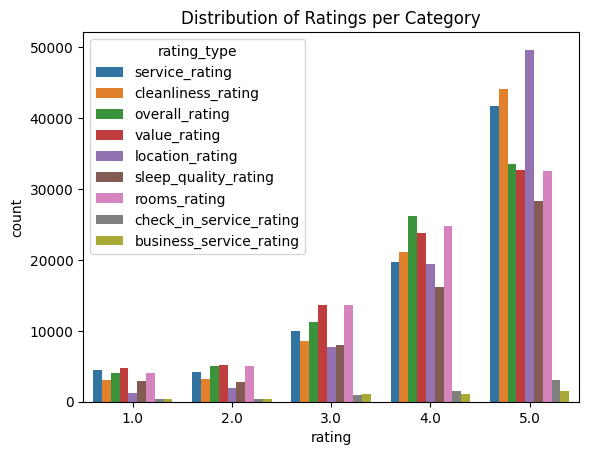

In [21]:
review_num_cols = [
    'service_rating',
    'cleanliness_rating',
    'overall_rating',
    'value_rating',
    'location_rating',
    'sleep_quality_rating',
    'rooms_rating',
    'check_in_service_rating',
    'business_service_rating'
]

long_df = reviews_df[review_num_cols].melt(
    var_name="rating_type",
    value_name="rating"
)

sns.countplot(
    data=long_df,
    x="rating",
    hue="rating_type"
)
plt.title("Distribution of Ratings per Category")
plt.show()


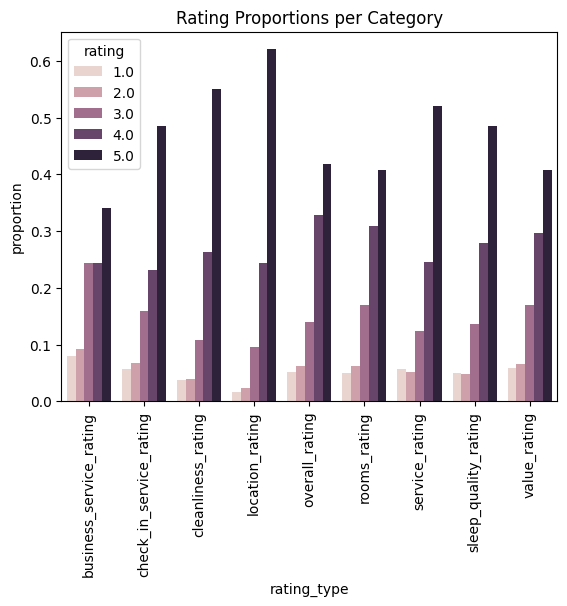

In [22]:
dist = (
    long_df
    .groupby(["rating_type", "rating"])
    .size()
    .reset_index(name="count")
)

dist["proportion"] = dist["count"] / dist.groupby("rating_type")["count"].transform("sum")


sns.barplot(
    data=dist,
    x="rating_type",
    y="proportion",
    hue="rating"
)
plt.xticks(rotation=90)
plt.title("Rating Proportions per Category")
plt.show()


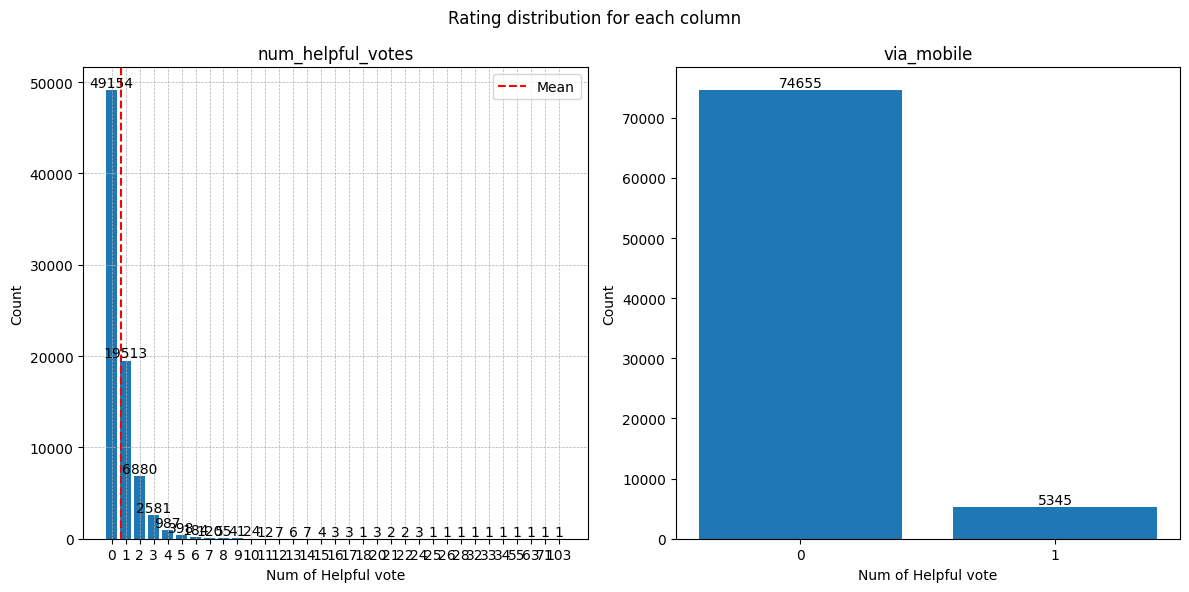

In [23]:
rating_column = [
    'num_helpful_votes',
    'via_mobile',
]

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
ax = ax.flatten()

for i, col in enumerate(rating_column):
    mean = reviews_df[col].mean()
    reviews_df_filled = reviews_df[col].fillna('NaN').astype(str)
    counts = reviews_df_filled.value_counts().sort_index(key=lambda x: pd.to_numeric(x, errors='coerce'))
    
    
    bars = ax[i].bar(counts.index, counts.values)
    
    # Add counts on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax[i].text(bar.get_x() + bar.get_width()/2, height + 1, str(height), ha='center', va='bottom', fontsize=10)
    
    if col == 'num_helpful_votes':
        ax[i].axvline(mean, color='red', linestyle='--', label='Mean')
        ax[i].legend()
        
    ax[i].set_title(f'{col}')
    ax[i].set_xlabel('Num of Helpful vote')
    ax[i].set_ylabel('Count')

ax[0].grid(linestyle = '--', linewidth = 0.5)

plt.suptitle('Rating distribution for each column')
plt.tight_layout()
plt.show()

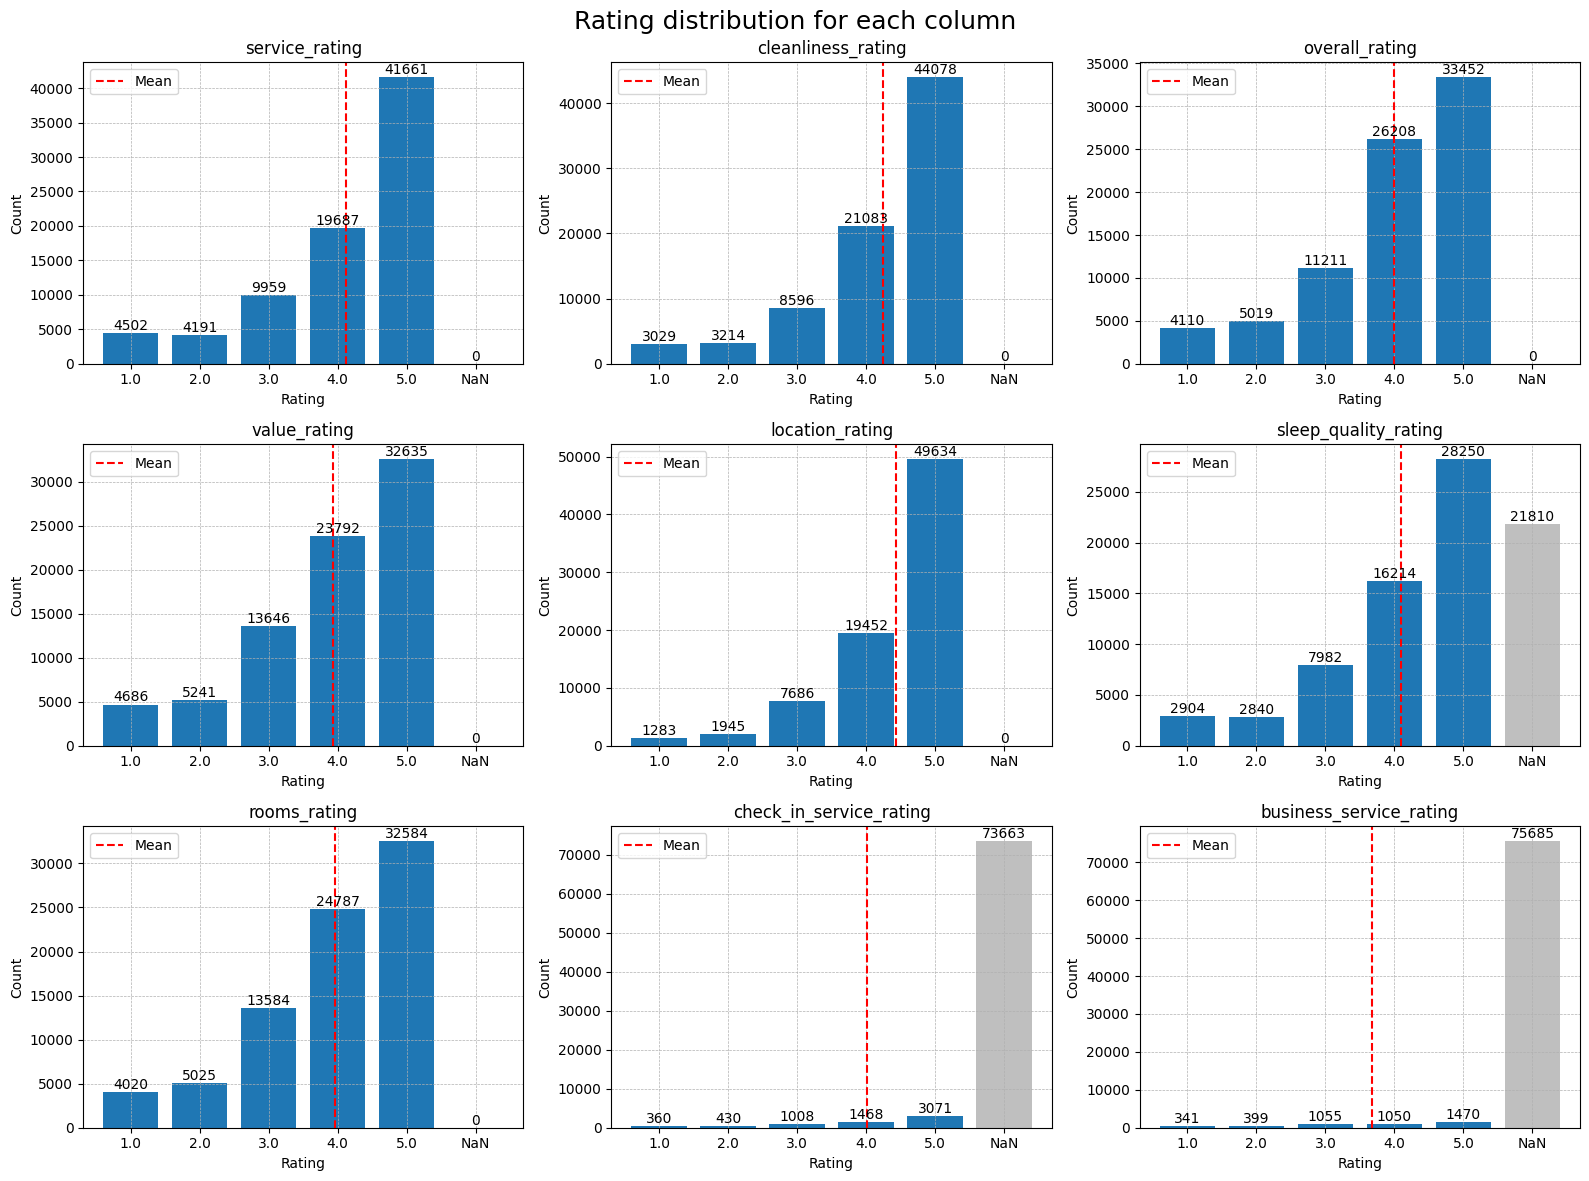

In [24]:
rating_column = [
    'service_rating',
    'cleanliness_rating',
    'overall_rating',
    'value_rating',
    'location_rating',
    'sleep_quality_rating',
    'rooms_rating',
    'check_in_service_rating',
    'business_service_rating'
]

fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(16,12))
ax = ax.flatten()

for i, col in enumerate(rating_column):
    mean = reviews_df[col].mean()
    
    reviews_df_filled = reviews_df[col].fillna('NaN').astype(str)
    counts = reviews_df_filled.value_counts()
    
    counts = counts.reindex(['1.0', '2.0', '3.0', '4.0', '5.0', 'NaN'], fill_value=0)
    colors = ['C0'] * 5 + ['gray']
    
    bars = ax[i].bar(counts.index, counts.values, color=colors)
    
    # Add counts on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax[i].text(bar.get_x() + bar.get_width()/2, height + 1, str(height), ha='center', va='bottom', fontsize=10)
    
    # Set the alpha of the NaN to 0.7
    bars[-1].set_alpha(0.5)
    
    # Map numeric mean to bar position
    x_labels = ['1.0', '2.0', '3.0', '4.0', '5.0']
    x_positions = np.arange(len(x_labels))
    
    # Only draw mean if numeric, ignore NaN
    if not np.isnan(mean):
        # Find position on x-axis
        mean_pos = mean - 1  # Subtract position by 1
        ax[i].axvline(mean_pos, color='red', linestyle='--', label='Mean')
        ax[i].legend()
        
    ax[i].set_title(f'{col}')
    ax[i].set_xlabel('Rating')
    ax[i].set_ylabel('Count')
    ax[i].grid(linestyle = '--', linewidth = 0.5)

plt.suptitle('Rating distribution for each column', fontsize=18)
plt.tight_layout()
plt.show()

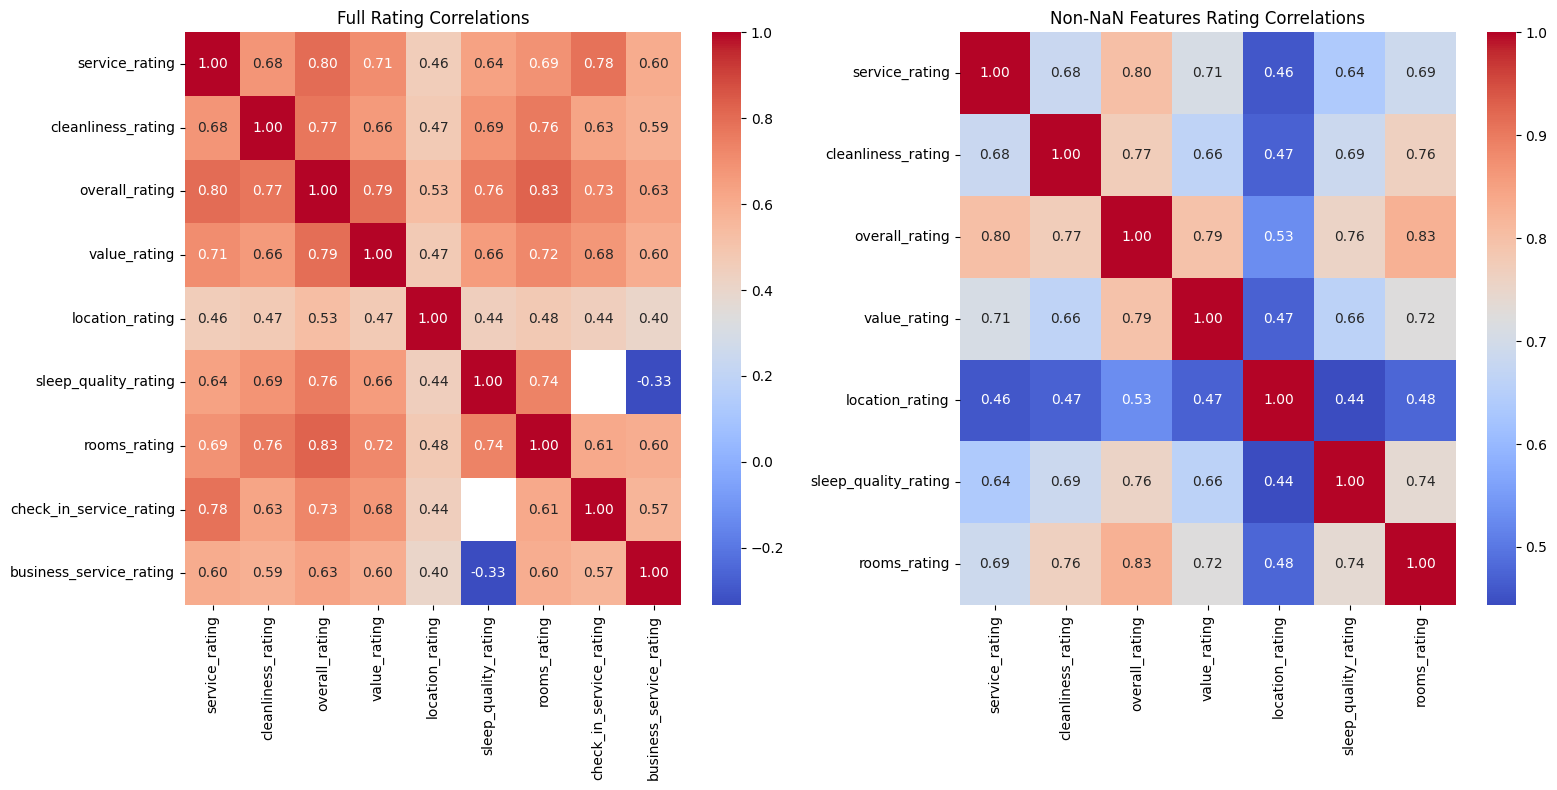

In [25]:
corr = reviews_df[[
    'service_rating',
    'cleanliness_rating',
    'overall_rating',
    'value_rating',
    'location_rating',
    'sleep_quality_rating',
    'rooms_rating',
    'check_in_service_rating',
    'business_service_rating'
    ]].corr()

corr_non_NaN = reviews_df[[
    'service_rating',
    'cleanliness_rating',
    'overall_rating',
    'value_rating',
    'location_rating',
    'sleep_quality_rating',
    'rooms_rating',
    ]].corr()


# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    ax=axes[0]
)
axes[0].set_title("Full Rating Correlations")

sns.heatmap(
    corr_non_NaN,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    ax=axes[1]
)
axes[1].set_title("Non-NaN Features Rating Correlations")

plt.tight_layout()
plt.show()

### 2.2. Authors Table

In [26]:
authors_df = dataset['authors']
authors_df.head()

,id,username,num_cities,num_helpful_votes,num_reviews,num_type_reviews,location,alias
0,51C01BDB846DFAA437A89BC08E86BF06,Pnemiller,284.0,883.0,935.0,134.0,"Kutztown, Pennsylvania",
1,CFC0ED785C821E20D403A851C40C5422,texaswillie,221.0,388.0,855.0,112.0,"Dallas, Texas",
2,3F75FA2DE3464A75D56B30470C0EA060,tymetraveler222,217.0,NaN,701.0,100.0,"Bay City, Michigan",
3,FF09B0D2C8126CC12D54B28424BE585D,BrunoldL,167.0,216.0,607.0,118.0,"Klosterneuburg, Austria",
4,03C0F1D9123788CA0A625769BDE3F313,bwco,131.0,NaN,559.0,48.0,"Morris County, NJ",


In [27]:
print(f'Number of entries in the authors dataframe: {len(authors_df):,} entries')

Number of entries in the authors dataframe: 75,349 entries


In [28]:
authors_df.columns

Index(['id', 'username', 'num_cities', 'num_helpful_votes', 'num_reviews',
       'num_type_reviews', 'location', 'alias'],
      dtype='str')

In [29]:
authors_df.describe()

,num_cities,num_helpful_votes,num_reviews,num_type_reviews
count,54659.000000,58204.000000,75349.000000,44724.000000
mean,11.844893,16.281974,15.659438,12.764265
std,13.250976,32.315139,25.716283,14.381042
min,2.000000,1.000000,1.000000,3.000000
25%,4.000000,2.000000,2.000000,5.000000
50%,8.000000,7.000000,7.000000,8.000000
75%,15.000000,18.000000,20.000000,15.000000
max,284.000000,964.000000,935.000000,275.000000


In [30]:
authors_df['location'].value_counts()

location
                                      4336
New York City, New York                943
London, United Kingdom                 771
Chicago, Illinois                      655
London                                 631
                                      ... 
Bicester                                 1
stewartsville                            1
SAN PEDRO                                1
Vicksburg, MS                            1
Hanford, California, United States       1
Name: count, Length: 19255, dtype: int64

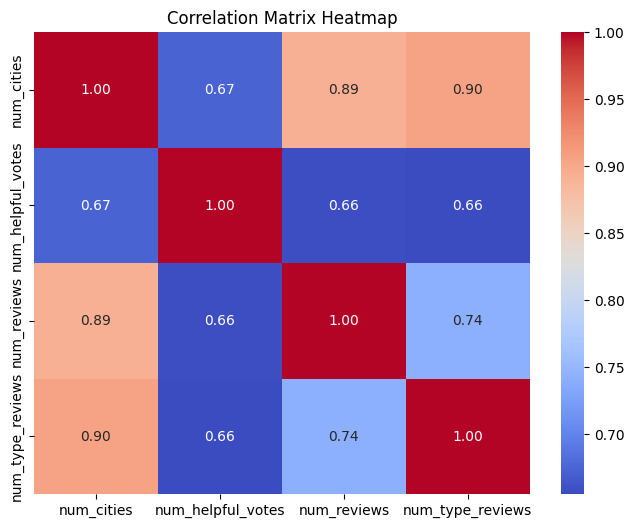

In [31]:
corr = authors_df[['num_cities', 'num_helpful_votes', 'num_reviews', 'num_type_reviews']].corr()

plt.figure(figsize=(8, 6)) # Adjust figure size as needed
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

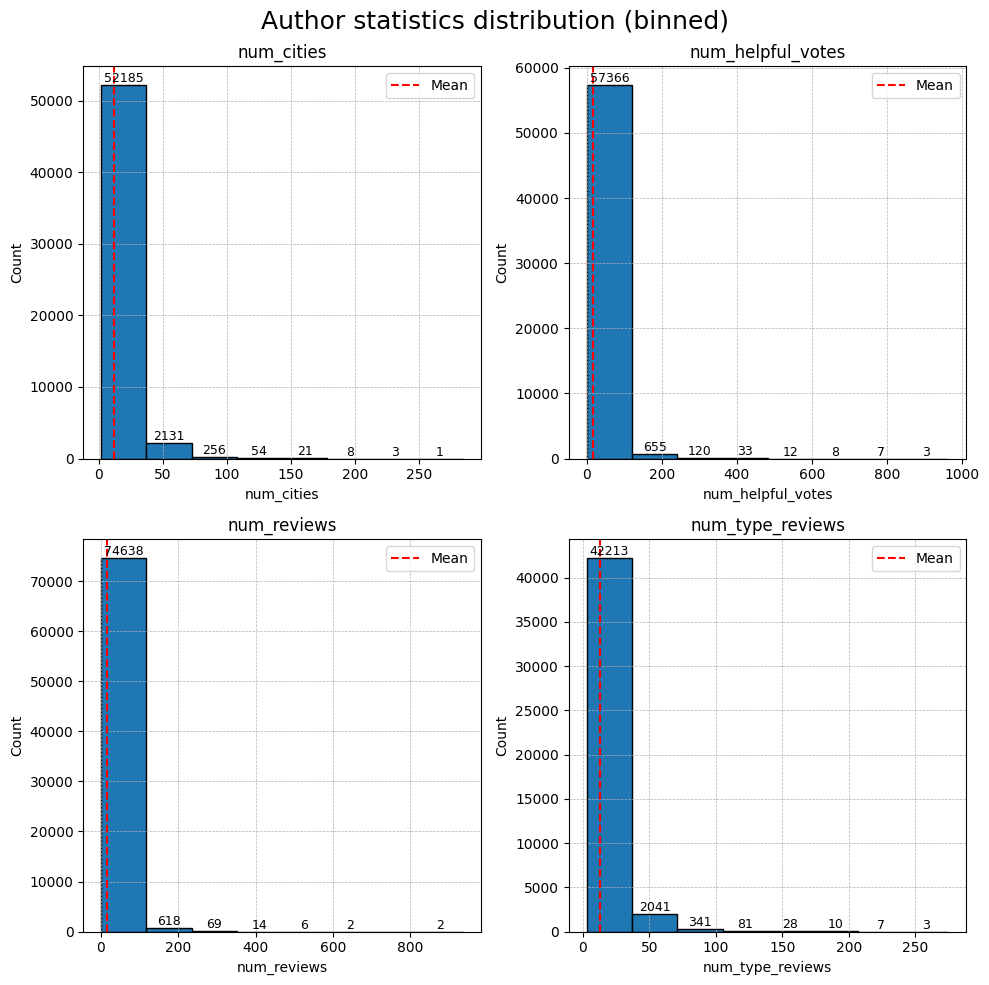

In [32]:
author_column = [
    'num_cities',
    'num_helpful_votes',
    'num_reviews',
    'num_type_reviews'
]

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
ax = ax.flatten()

for i, col in enumerate(author_column):
    mean = authors_df[col].mean()
    
    authors_df_filled = authors_df[col].fillna('NaN').astype(str)
    counts = authors_df_filled.value_counts()
    
    
    counts, bin_edges, bars = ax[i].hist(
        authors_df[col],
        bins=8,
        edgecolor='black'
    )

    # Add count labels on top of bars
    for count, bar in zip(counts, bars):
        if count > 0:
            ax[i].text(
                bar.get_x() + bar.get_width()/2,
                count,
                int(count),
                ha='center',
                va='bottom',
                fontsize=9
            )

    # Mean line
    ax[i].axvline(mean, color='red', linestyle='--', label='Mean')
    ax[i].legend()

    ax[i].set_title(col)
    ax[i].set_xlabel(col)
    ax[i].set_ylabel('Count')
    ax[i].grid(linestyle='--', linewidth=0.5)

plt.suptitle('Author statistics distribution (binned)', fontsize=18)
plt.tight_layout()
plt.show()

### 2.3. Hotels table

In [33]:
hotels_df = dataset['hotels']
hotels_df.head()

,hotel_id,num_reviews,avg_service_rating,avg_cleanliness_rating,avg_overall_rating,avg_value_rating,avg_location_rating,avg_sleep_quality_rating,avg_rooms_rating,avg_check_in_service_rating,avg_business_service_rating
0,214197,1825,2.363836,2.306301,2.261370,2.617534,4.433425,2.595794,2.065205,2.421053,2.265306
1,122005,1774,3.911499,4.221533,3.949267,3.858512,4.665163,4.098581,3.717587,3.623377,3.843137
2,93520,1739,3.522714,3.600920,3.550316,3.557217,4.687752,3.813973,3.456009,2.994012,2.568182
3,93562,1685,4.252819,4.217804,4.077151,4.016617,4.670623,3.936960,3.997033,4.369369,3.757576
4,93618,1647,3.993321,4.101396,3.828780,3.408622,4.602914,4.099425,3.680631,4.134328,3.474359


In [34]:
print(f'Length of hotels_df: {len(hotels_df):,}')

Length of hotels_df: 3,380


In [35]:
hotels_df.describe()

,num_reviews,avg_service_rating,avg_cleanliness_rating,avg_overall_rating,avg_value_rating,avg_location_rating,avg_sleep_quality_rating,avg_rooms_rating,avg_check_in_service_rating,avg_business_service_rating
count,3380.000000,3380.000000,3380.000000,3380.000000,3380.000000,3380.000000,3347.000000,3380.000000,2503.000000,2384.000000
mean,148.263609,3.848832,3.903125,3.654028,3.750639,4.056105,3.787525,3.670522,3.825460,3.560001
std,218.972431,0.731526,0.806769,0.785323,0.664928,0.649463,0.738412,0.788405,0.872021,0.940848
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,23.000000,3.571200,3.600000,3.332237,3.500000,3.752552,3.500000,3.299899,3.451613,3.000000
50%,60.500000,4.030892,4.138090,3.833333,3.884615,4.191622,3.987342,3.844960,4.000000,3.687500
75%,184.000000,4.343800,4.468659,4.200505,4.187889,4.533333,4.293641,4.227553,4.444444,4.200000
max,1825.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


num_reviews


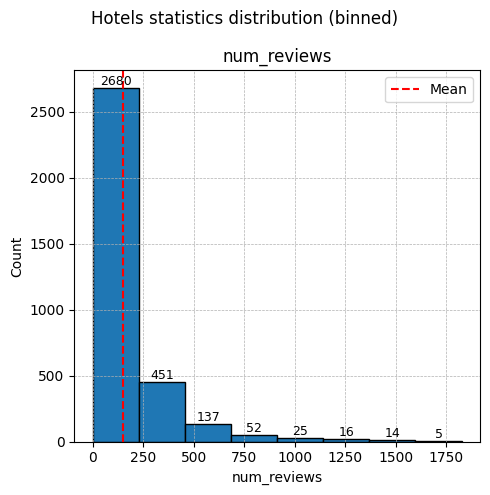

In [36]:
hotel_column = [
    'num_reviews',
]

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,5))

for i, col in enumerate(hotel_column):
    print(col)
    mean = hotels_df[col].mean()
    
    hotels_df_filled = hotels_df[col].fillna('NaN').astype(str)
    counts = hotels_df_filled.value_counts()
    
    
    counts, bin_edges, bars = ax.hist(
        hotels_df[col],
        bins=8,
        edgecolor='black'
    )

    # Add count labels on top of bars
    for count, bar in zip(counts, bars):
        if count > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                count,
                int(count),
                ha='center',
                va='bottom',
                fontsize=9
            )

    # Mean line
    ax.axvline(mean, color='red', linestyle='--', label='Mean')
    ax.legend()

    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.grid(linestyle='--', linewidth=0.5)

plt.suptitle('Hotels statistics distribution (binned)')
plt.tight_layout()
plt.show()

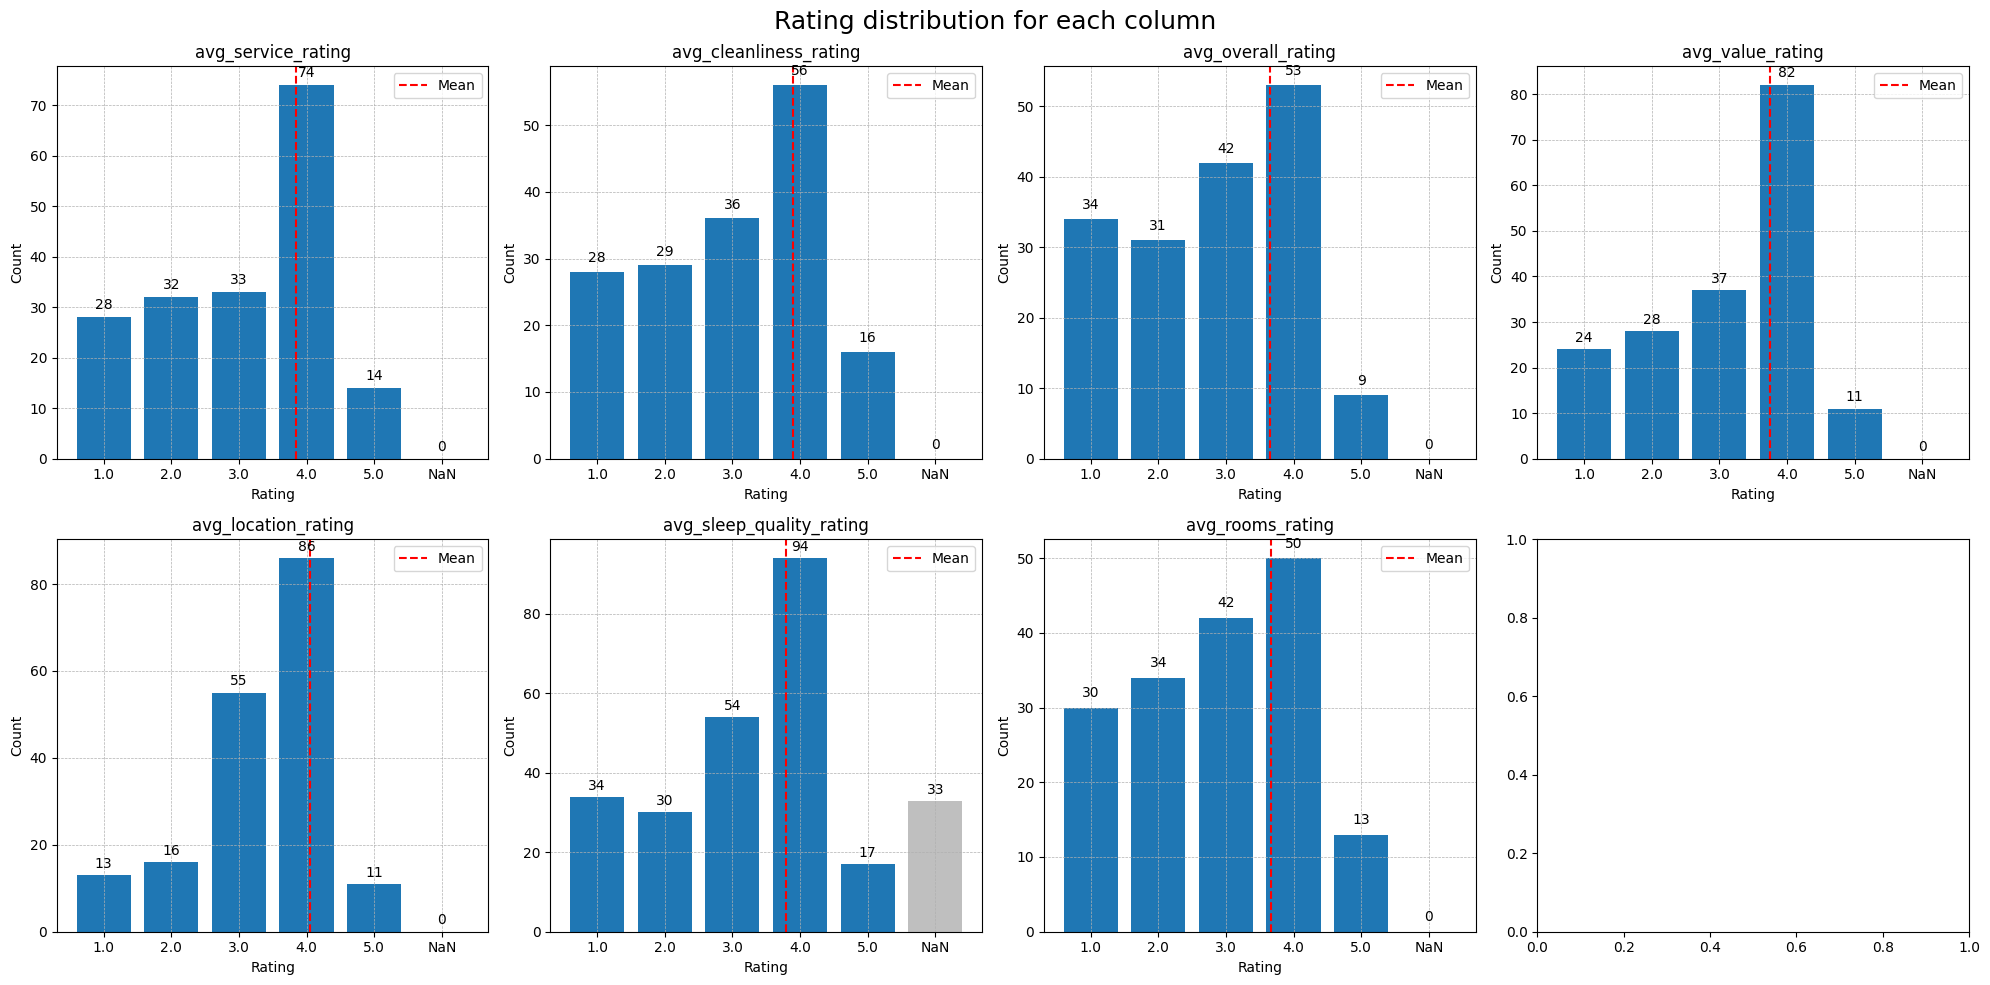

In [37]:
hotel_column = [
    'avg_service_rating',
    'avg_cleanliness_rating',
    'avg_overall_rating',
    'avg_value_rating',
    'avg_location_rating',
    'avg_sleep_quality_rating',
    'avg_rooms_rating',
]

fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(20,10))
ax = ax.flatten()

for i, col in enumerate(hotel_column):
    mean = hotels_df[col].mean()
    
    hotels_df_filled = hotels_df[col].fillna('NaN').astype(str)
    counts = hotels_df_filled.value_counts()
    
    counts = counts.reindex(['1.0', '2.0', '3.0', '4.0', '5.0', 'NaN'], fill_value=0)
    colors = ['C0'] * 5 + ['gray']
    
    bars = ax[i].bar(counts.index, counts.values, color=colors)
    
    # Add counts on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax[i].text(bar.get_x() + bar.get_width()/2, height + 1, str(height), ha='center', va='bottom', fontsize=10)
    
    # Set the alpha of the NaN to 0.7
    bars[-1].set_alpha(0.5)
    
    # Map numeric mean to bar position
    # x_labels = ['1.0', '2.0', '3.0', '4.0', '5.0']
    # x_positions = np.arange(len(x_labels))
    
    # Only draw mean if numeric, ignore NaN
    if not np.isnan(mean):
        # Find position on x-axis
        mean_pos = mean - 1  # Subtract position by 1
        ax[i].axvline(mean_pos, color='red', linestyle='--', label='Mean')
        ax[i].legend()
        
    ax[i].set_title(f'{col}')
    ax[i].set_xlabel('Rating')
    ax[i].set_ylabel('Count')
    ax[i].grid(linestyle = '--', linewidth = 0.5)

plt.suptitle('Rating distribution for each column', fontsize=18)
plt.tight_layout()
plt.show()

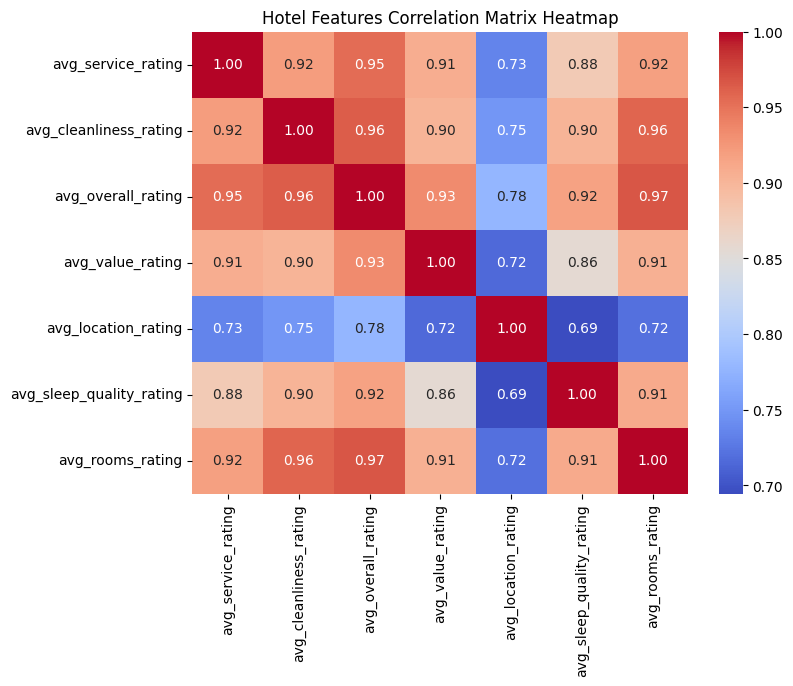

In [38]:
corr = hotels_df[['avg_service_rating',
    'avg_cleanliness_rating',
    'avg_overall_rating',
    'avg_value_rating',
    'avg_location_rating',
    'avg_sleep_quality_rating',
    'avg_rooms_rating',
]].corr()

plt.figure(figsize=(8, 6)) # Adjust figure size as needed
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Hotel Features Correlation Matrix Heatmap')
plt.show()

---

## 3. Feature Engineering

### **review_frequency** (authors_df)

Whether an author frequently write reviews compared to the median of all authors.

In [39]:
authors_df.head(2)

,id,username,num_cities,num_helpful_votes,num_reviews,num_type_reviews,location,alias
0,51C01BDB846DFAA437A89BC08E86BF06,Pnemiller,284.0,883.0,935.0,134.0,"Kutztown, Pennsylvania",
1,CFC0ED785C821E20D403A851C40C5422,texaswillie,221.0,388.0,855.0,112.0,"Dallas, Texas",


We need to check the skewness of the data before doing the threshold, therefore let's visualize the feature

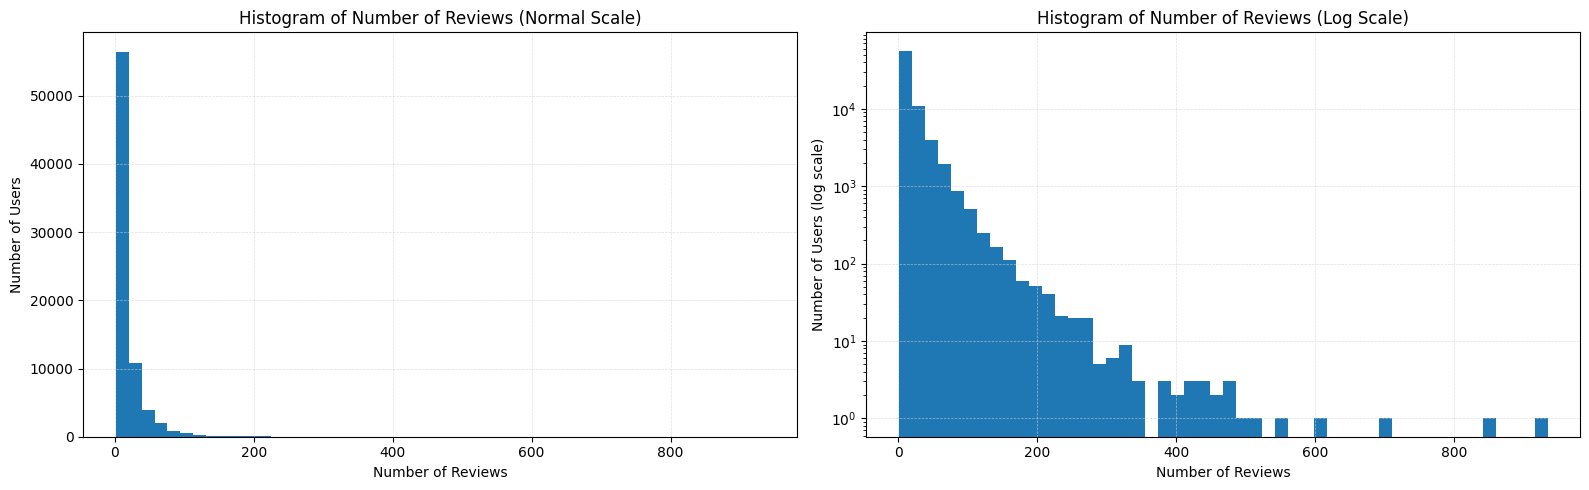

In [40]:
authors_df['num_reviews'].value_counts()

# Create a figure with 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16,5))

# Normal scale histogram
axes[0].hist(authors_df['num_reviews'], bins=50)
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('Histogram of Number of Reviews (Normal Scale)')
axes[0].grid(True, color='lightgray', linestyle='--', linewidth=0.5, alpha=0.7)

# Log scale histogram
axes[1].hist(authors_df['num_reviews'], bins=50, log=True)
axes[1].set_xlabel('Number of Reviews')
axes[1].set_ylabel('Number of Users (log scale)')
axes[1].set_title('Histogram of Number of Reviews (Log Scale)')
axes[1].grid(True, color='lightgray', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()


The heavy skewness makes it hard to use simple thresholding with mean, std, or median. Our approach will use the quantile based categorization so that we have a balanced category.

In [41]:
# Set the quantile
q1 = authors_df['num_reviews'].quantile(0.33)
q2 = authors_df['num_reviews'].quantile(0.66)

print('=' * 40)
print('category')
print('=' * 40)
print(f'range from 0 - {q1} ===> Low')
print(f'range from {q1} - {q2} ===> Medium')
print(f'range from {q2} - infinity ===> High')
print('=' * 40)

def categorize_reviews(n):
    if n <= q1:
        return 'low'
    elif n <= q2:
        return 'medium'
    else:
        return 'high'

authors_df['review_frequency'] = authors_df['num_reviews'].apply(categorize_reviews)

category
range from 0 - 3.0 ===> Low
range from 3.0 - 13.0 ===> Medium
range from 13.0 - infinity ===> High


In [43]:
for freq in ['low', 'medium', 'high']:
    print(f"{freq.upper()} frequency total: {len(authors_df[authors_df['review_frequency'] == freq]):,}")

LOW frequency total: 28,732
MEDIUM frequency total: 21,495
HIGH frequency total: 25,122


In [44]:
# IF USING MEAN STD OR MEDIAN
freq_df = authors_df.copy()

mean = freq_df['num_reviews'].mean()
median = freq_df['num_reviews'].median()
std = freq_df['num_reviews'].std()

freq_df['freq_mean'] = freq_df['num_reviews'] > mean
freq_df['freq_mean_std'] = freq_df['num_reviews'] > (mean + std)
freq_df['freq_median'] = freq_df['num_reviews'] > median

for freq in ['freq_mean', 'freq_mean_std', 'freq_median']:
    print(f'\n{freq}')
    print(f'frequent: {freq_df[freq].sum():,}')
    print(f'not frequent: {len(freq_df) - (freq_df[freq].sum()):,}')


freq_mean
frequent: 22,493
not frequent: 52,856

freq_mean_std
frequent: 7,252
not frequent: 68,097

freq_median
frequent: 35,274
not frequent: 40,075


Using the mean and std will make the class very unstable.

Using median might be a good choice, but it will only allow binary categorization instead of multi level category.

In [45]:
authors_df.sample(10)

,id,username,num_cities,num_helpful_votes,num_reviews,num_type_reviews,location,alias,review_frequency
41358,EA03BD033D10FBFC8B02E7CA6CAD07D9,spikeTX,4.0,8.0,5.0,4.0,"Dallas, TX",,medium
35175,423DDC6AD03B62B69ECC3AA584318D2A,apliego,12.0,5.0,8.0,8.0,Monterrey,,medium
58802,00E0BB97C1AE6F1F2CFB498EF78378DA,sandpiperx1,NaN,1.0,1.0,NaN,"Denton, Texas",,low
24957,399BF0A9BF5F056CBC142518B98530DC,CristinaSim,9.0,9.0,14.0,8.0,"Toronto, Canada",,high
23324,42254ADD5329902FA7F71E7A3DA4E871,mariamom,8.0,8.0,15.0,7.0,Denver,,high
3246,7D4D80E9ADF3E9CF676BD9781D6D9754,ms9,51.0,79.0,64.0,48.0,"Chicago, Illinois",,high
38753,89AE46069C854977FECFAABA1BF0EDCF,TheDynamicDuoLohberg,5.0,4.0,6.0,3.0,Lohberg,,medium
55564,6C045CD8B714ECD2BEA87BD3695817C4,nawtyme,2.0,2.0,2.0,NaN,"Incline Village, Nevada, USA",,low
25005,56CFE054E376ADD08B437927CF7BBCFD,Denis C,7.0,5.0,14.0,7.0,"Trenton, Canada",,high
27036,65359E1C266D99B48E82139BC882C0E4,JDG2010,4.0,1.0,12.0,4.0,"Phoenix, Arizona",,medium


For the visualization

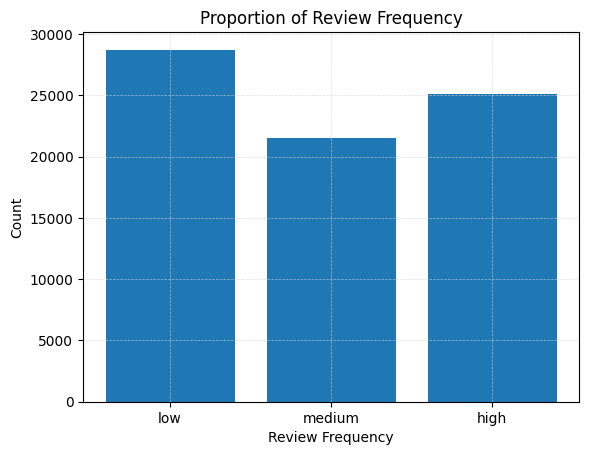

In [46]:
freq_counts = authors_df['review_frequency'].value_counts()

order = ['low', 'medium', 'high']
freq_counts = freq_counts.reindex(order, fill_value=0)

# Plot
plt.grid(True, color='lightgray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.bar(freq_counts.index, freq_counts.values)
plt.xlabel("Review Frequency")
plt.ylabel("Count")
plt.title("Proportion of Review Frequency")
plt.show()

### **helpful_votes_ratio** (authors_df)

Ratio of how many helpful reviews produced by the user compared to the number of reviews published

* formula: number of helpful votes / number of reviews

In [47]:
# Fill NaN to prevent error
authors_df[['num_helpful_votes', 'num_reviews']] = authors_df[['num_helpful_votes', 'num_reviews']].fillna(0)

# Check validity if helpful notes is larger than num_reviews (invalid)
authors_df['num_helpful_votes'] = authors_df[['num_helpful_votes', 'num_reviews']].min(axis=1)

authors_df['helpful_votes_ratio'] = np.where(
    (authors_df['num_helpful_votes'] == 0) | (authors_df['num_reviews'] == 0), 0, authors_df['num_helpful_votes'] / authors_df['num_reviews']
)

authors_df

,id,username,num_cities,num_helpful_votes,num_reviews,num_type_reviews,location,alias,review_frequency,helpful_votes_ratio
0,51C01BDB846DFAA437A89BC08E86BF06,Pnemiller,284.0,883.0,935.0,134.0,"Kutztown, Pennsylvania",,high,0.944385
1,CFC0ED785C821E20D403A851C40C5422,texaswillie,221.0,388.0,855.0,112.0,"Dallas, Texas",,high,0.453801
2,3F75FA2DE3464A75D56B30470C0EA060,tymetraveler222,217.0,0.0,701.0,100.0,"Bay City, Michigan",,high,0.000000
3,FF09B0D2C8126CC12D54B28424BE585D,BrunoldL,167.0,216.0,607.0,118.0,"Klosterneuburg, Austria",,high,0.355848
4,03C0F1D9123788CA0A625769BDE3F313,bwco,131.0,0.0,559.0,48.0,"Morris County, NJ",,high,0.000000
...,...,...,...,...,...,...,...,...,...,...
75344,4C10B11D24267344DDA95FF18C85B2D4,Rosemary R,NaN,0.0,1.0,NaN,"El Paso, Texas, United States",,low,0.000000
75345,B803C1CBA21D2FFF3E49359414B22160,tiggywiggy210,NaN,1.0,1.0,NaN,"Calgary, Canada",,low,1.000000
75346,B8064FA237693394801E1BAECDD611AC,Pamela W,NaN,0.0,1.0,NaN,"Vancouver, BC",,low,0.000000
75347,B806DDF2B11D9158815CDDA1D8352A66,bhongllesis,NaN,0.0,1.0,NaN,"Seattle, Washington",,low,0.000000


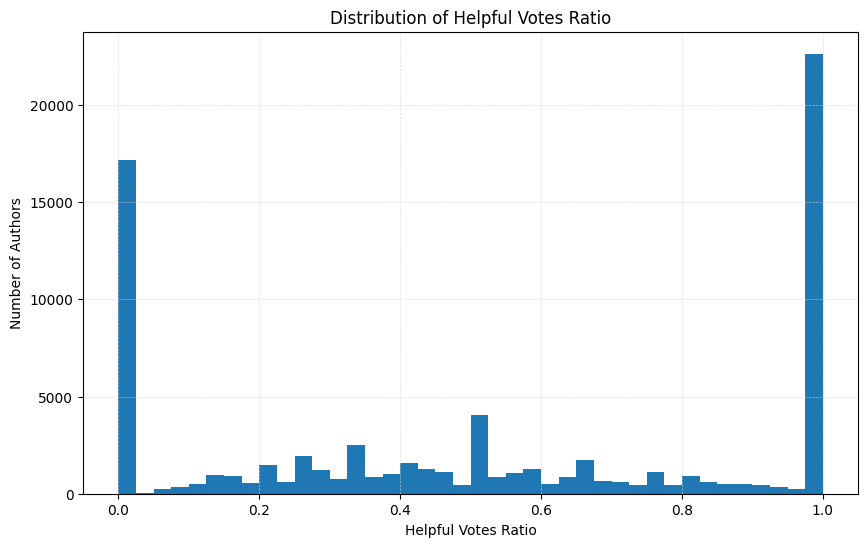

In [48]:
plt.figure(figsize=(10,6))
plt.hist(authors_df['helpful_votes_ratio'], bins=40)
plt.xlabel('Helpful Votes Ratio')
plt.ylabel('Number of Authors')
plt.title('Distribution of Helpful Votes Ratio')
plt.grid(True, color='lightgray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()

### **avg_stars_given** authors_df

Average of stars given by a user in all their reviews

* formula: mean of all stars given in reviews dataframe.

In [49]:
reviews_df

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id,date_stayed_dt,reviews_days_since_stay
0,“Daaaaaa Bears!”,I recently stayed at W Chicago Lakeshore and o...,2012-11-01,225108,0,2012-11-19,145753174,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,714F49AC057498AEA304343E569A2A03,2012-11-01,18 days
1,“Would go back in a heartbeat- Location Locati...,We booked this hotel after out initial travel ...,2010-09-01,122005,1,2010-10-02,81870377,0,3.0,5.0,4.0,5.0,5.0,5.0,3.0,NaN,NaN,74C5A4455E1AAE46B0C54FC6CCBD7033,2010-09-01,31 days
2,"“Clean, Friendly, Affordable Alternative to Do...",I am currently here in the hotel; checking out...,2009-07-01,939375,2,2009-07-02,33732815,0,5.0,4.0,4.0,4.0,4.0,NaN,4.0,NaN,NaN,CC2C523A197E7024A07BE083E1573E75,2009-07-01,1 days
3,"“Atrium pool, location and basic amenities wer...",Two 10 yr. olds enjoyed the large pool in the ...,2009-06-01,87573,1,2009-06-21,32773886,0,3.0,4.0,4.0,4.0,4.0,NaN,3.0,NaN,NaN,D879DE1351CB445AEF3B247EF25CFC00,2009-06-01,20 days
4,“Very Good but Nothing Spectacular”,Stayed here on business because it was within ...,2009-08-01,123022,0,2009-08-19,38157829,0,4.0,5.0,4.0,3.0,3.0,NaN,3.0,NaN,NaN,404B9AF8897A742142CEBF4F0596EF5E,2009-08-01,18 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,“Oops. Not the best choice for me.”,"The W Boston should have been better for me, b...",2009-12-01,1486034,0,2009-12-07,50826156,0,4.0,2.0,3.0,2.0,4.0,NaN,3.0,NaN,NaN,309A277A5D221634DA28090144520A10,2009-12-01,6 days
79996,“My favorite hotel in Seattle”,The Alexis is the best. The service is always ...,2012-01-01,112412,0,2012-01-30,123858080,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,8C7A26020CD00F6C88B7A2537AB0F3BE,2012-01-01,29 days
79997,“Good but to hot”,This hotel needs aircon the rooms are to warm ...,2011-09-01,115644,1,2011-10-06,118987846,0,5.0,5.0,4.0,3.0,5.0,3.0,4.0,NaN,NaN,0AAFAB9A0D356BCF6E56DCDA6ECD73D2,2011-09-01,35 days
79998,“Everything you would expect from a 4 star pro...,I had a late evening flight into Houstons Hobb...,2011-05-01,1549134,0,2011-05-26,109895397,0,5.0,5.0,5.0,4.0,5.0,5.0,4.0,NaN,NaN,220F304A84F86A2E5AF856F270C775D5,2011-05-01,25 days


In [50]:
stars_df = reviews_df[['review_id', 'author_id', 'service_rating', 'cleanliness_rating', 'overall_rating', 	'value_rating', 'location_rating', 'sleep_quality_rating', 'rooms_rating', 'check_in_service_rating', 'business_service_rating']].copy()
stars_df['author_id'].isna().sum()

stars_df


,review_id,author_id,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating
0,145753174,714F49AC057498AEA304343E569A2A03,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN
1,81870377,74C5A4455E1AAE46B0C54FC6CCBD7033,3.0,5.0,4.0,5.0,5.0,5.0,3.0,NaN,NaN
2,33732815,CC2C523A197E7024A07BE083E1573E75,5.0,4.0,4.0,4.0,4.0,NaN,4.0,NaN,NaN
3,32773886,D879DE1351CB445AEF3B247EF25CFC00,3.0,4.0,4.0,4.0,4.0,NaN,3.0,NaN,NaN
4,38157829,404B9AF8897A742142CEBF4F0596EF5E,4.0,5.0,4.0,3.0,3.0,NaN,3.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
79995,50826156,309A277A5D221634DA28090144520A10,4.0,2.0,3.0,2.0,4.0,NaN,3.0,NaN,NaN
79996,123858080,8C7A26020CD00F6C88B7A2537AB0F3BE,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN
79997,118987846,0AAFAB9A0D356BCF6E56DCDA6ECD73D2,5.0,5.0,4.0,3.0,5.0,3.0,4.0,NaN,NaN
79998,109895397,220F304A84F86A2E5AF856F270C775D5,5.0,5.0,5.0,4.0,5.0,5.0,4.0,NaN,NaN


In [51]:
rating_cols = [
    'service_rating', 'cleanliness_rating', 'overall_rating', 'value_rating',
    'location_rating', 'sleep_quality_rating', 'rooms_rating', 'check_in_service_rating',
    'business_service_rating'
]

stars_df = stars_df.groupby('author_id')[rating_cols].mean()
stars_df['final_overall_avg'] = stars_df.mean(axis=1)

# Reset index and rename to align with authors_df
stars_df.reset_index(inplace=True)
stars_df.rename(columns={'author_id': 'id'}, inplace=True)
stars_df.sample(100)

,id,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,final_overall_avg
30405,673BDF83EB4B503FAB282EDEFA1D3207,4.0,4.0,4.0,5.0,5.0,4.0,4.0,NaN,NaN,4.285714
347,011BBC72B14505C1DF8CFD36E4C07537,5.0,5.0,5.0,5.0,4.0,5.0,5.0,NaN,NaN,4.857143
71035,F1BFBBCFE9771DAB2C2721AECC2D7ADB,5.0,5.0,5.0,5.0,5.0,NaN,5.0,NaN,NaN,5.000000
46654,9E7DE1DFF7F03C0C76207E9788C634D0,4.0,4.0,4.0,4.0,4.0,NaN,5.0,4.0,NaN,4.142857
1089,039518F1E432502F7A9AE7A503A88F7B,5.0,5.0,5.0,4.0,5.0,4.0,5.0,NaN,NaN,4.714286
...,...,...,...,...,...,...,...,...,...,...,...
47543,A1BE0F15804C1740A8A43955E649747B,4.0,5.0,4.0,4.0,5.0,NaN,4.0,NaN,NaN,4.333333
52398,B1CA1E776C652D597D1AF82F38B4E738,4.0,4.0,4.0,4.0,5.0,4.0,5.0,NaN,NaN,4.285714
42126,8EDF8A378AFCF05DBA4F67A5084593FE,1.0,2.0,1.0,1.0,1.0,2.0,1.0,NaN,NaN,1.285714
5840,13A4B834D70FFCD1080D600D168EFD1F,3.0,3.0,4.0,3.0,5.0,NaN,3.0,NaN,NaN,3.500000


Merge the stars_df back to authors_df

In [52]:
authors_df = authors_df.merge(stars_df, on='id', how='left')
authors_df.sample(10)

,id,username,num_cities,num_helpful_votes,num_reviews,num_type_reviews,location,alias,review_frequency,helpful_votes_ratio,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,final_overall_avg
9334,ACF919F0B893D37CDB8285DF73C781F6,LesleyBoltonEngland,17.0,20.0,35.0,12.0,"Bolton, United Kingdom",,high,0.571429,5.0,4.0,4.0,4.0,5.0,NaN,5.0,NaN,NaN,4.500000
64070,67C3FEAF12BCD35859991172BDA3678D,Spiffydude,NaN,0.0,1.0,NaN,SG,,low,0.000000,4.0,4.0,4.0,4.0,5.0,NaN,4.0,4.0,2.0,3.875000
1298,A54B8830E4DD93AEDC4A9296D65B62C1,Amanjunkee,42.0,16.0,94.0,78.0,Berlin,,high,0.170213,3.0,5.0,4.0,4.0,3.0,5.0,4.0,NaN,NaN,4.000000
27983,C15949663144F8B0C7535F718620A17D,indiefilmmaker,5.0,1.0,12.0,NaN,"New York City, New York",,medium,0.083333,2.0,4.0,3.0,3.0,5.0,3.0,2.0,NaN,NaN,3.142857
67958,7F1BF0710BFBEDF294FEDF8251514981,Bunnykr,NaN,0.0,1.0,NaN,"Merced, California",,low,0.000000,5.0,5.0,5.0,5.0,5.0,4.0,5.0,NaN,NaN,4.857143
6434,3D5813140530004DF12BFC190071B95C,sds,17.0,45.0,45.0,12.0,,,high,1.000000,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,5.000000
45328,5044128CD6EB5CF459103BF1655C2EF3,Maryna2012,3.0,2.0,4.0,3.0,"Kiev, Ukraine",,medium,0.500000,5.0,4.0,4.0,4.0,4.0,2.0,3.0,NaN,NaN,3.714286
65451,A7C4D1F4F665CC35CC87ADCABED5291A,RevDean,NaN,0.0,1.0,NaN,"Las Cruces, New Mexico",,low,0.000000,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,5.000000
2540,733A30D772AD54C0814E0F3C14DE155C,mlasser,38.0,70.0,70.0,60.0,"Denver, Colorado",,high,1.000000,5.0,5.0,5.0,5.0,5.0,4.0,5.0,NaN,NaN,4.857143
31965,5D646E464F51C6EDB013BC76E8D46204,cdysly,5.0,0.0,9.0,4.0,"Paris, France",,medium,0.000000,4.0,4.0,4.0,4.0,5.0,4.0,4.0,NaN,NaN,4.142857


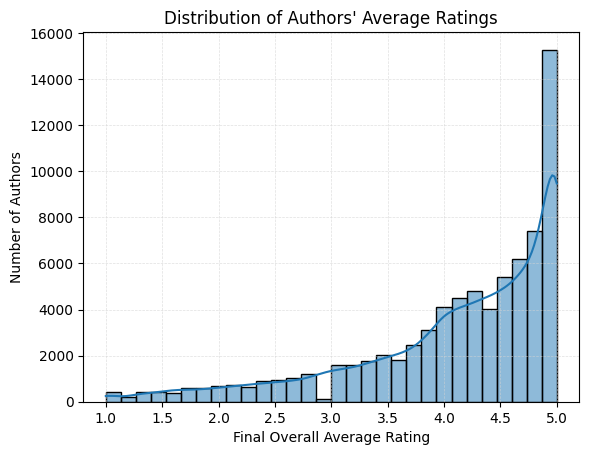

In [53]:
sns.histplot(authors_df['final_overall_avg'], bins=30, kde=True)
plt.xlabel("Final Overall Average Rating")
plt.ylabel("Number of Authors")
plt.title("Distribution of Authors' Average Ratings")
plt.grid(True, color='lightgray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()

You can see the tendencies of user giving 5 stars by default is very high. This proves that the authors will most likely give 5 stars ratings. Although this shows that the data is not skewed towards negative reviews, but having too much 5 stars ratings average can also add up complexity due to certain bias of the authors.

### **ratings_variance** (hotels_df)

Indicate whether a hotel consistently receives certain number of starts or not.

* formula: average of squared differences between each data point and the mean

In [54]:
reviews_df

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id,date_stayed_dt,reviews_days_since_stay
0,“Daaaaaa Bears!”,I recently stayed at W Chicago Lakeshore and o...,2012-11-01,225108,0,2012-11-19,145753174,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,714F49AC057498AEA304343E569A2A03,2012-11-01,18 days
1,“Would go back in a heartbeat- Location Locati...,We booked this hotel after out initial travel ...,2010-09-01,122005,1,2010-10-02,81870377,0,3.0,5.0,4.0,5.0,5.0,5.0,3.0,NaN,NaN,74C5A4455E1AAE46B0C54FC6CCBD7033,2010-09-01,31 days
2,"“Clean, Friendly, Affordable Alternative to Do...",I am currently here in the hotel; checking out...,2009-07-01,939375,2,2009-07-02,33732815,0,5.0,4.0,4.0,4.0,4.0,NaN,4.0,NaN,NaN,CC2C523A197E7024A07BE083E1573E75,2009-07-01,1 days
3,"“Atrium pool, location and basic amenities wer...",Two 10 yr. olds enjoyed the large pool in the ...,2009-06-01,87573,1,2009-06-21,32773886,0,3.0,4.0,4.0,4.0,4.0,NaN,3.0,NaN,NaN,D879DE1351CB445AEF3B247EF25CFC00,2009-06-01,20 days
4,“Very Good but Nothing Spectacular”,Stayed here on business because it was within ...,2009-08-01,123022,0,2009-08-19,38157829,0,4.0,5.0,4.0,3.0,3.0,NaN,3.0,NaN,NaN,404B9AF8897A742142CEBF4F0596EF5E,2009-08-01,18 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,“Oops. Not the best choice for me.”,"The W Boston should have been better for me, b...",2009-12-01,1486034,0,2009-12-07,50826156,0,4.0,2.0,3.0,2.0,4.0,NaN,3.0,NaN,NaN,309A277A5D221634DA28090144520A10,2009-12-01,6 days
79996,“My favorite hotel in Seattle”,The Alexis is the best. The service is always ...,2012-01-01,112412,0,2012-01-30,123858080,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,8C7A26020CD00F6C88B7A2537AB0F3BE,2012-01-01,29 days
79997,“Good but to hot”,This hotel needs aircon the rooms are to warm ...,2011-09-01,115644,1,2011-10-06,118987846,0,5.0,5.0,4.0,3.0,5.0,3.0,4.0,NaN,NaN,0AAFAB9A0D356BCF6E56DCDA6ECD73D2,2011-09-01,35 days
79998,“Everything you would expect from a 4 star pro...,I had a late evening flight into Houstons Hobb...,2011-05-01,1549134,0,2011-05-26,109895397,0,5.0,5.0,5.0,4.0,5.0,5.0,4.0,NaN,NaN,220F304A84F86A2E5AF856F270C775D5,2011-05-01,25 days


In [55]:
variance_df = reviews_df.copy()

rating_columns = [
    'service_rating', 'cleanliness_rating', 'overall_rating', 
    'value_rating', 'location_rating', 'sleep_quality_rating', 
    'rooms_rating', 'check_in_service_rating', 'business_service_rating'
]

variance_df = variance_df.groupby('hotel_id')[rating_columns].var(ddof=0)

variance_df = variance_df.reset_index()

variance_df = variance_df.rename(columns={col: f"{col}_variance" for col in variance_df.columns if col != 'hotel_id'})

In [56]:
hotels_df = hotels_df.merge(variance_df, on='hotel_id', how='left')
hotels_df.sample(10)

,hotel_id,num_reviews,avg_service_rating,avg_cleanliness_rating,avg_overall_rating,avg_value_rating,avg_location_rating,avg_sleep_quality_rating,avg_rooms_rating,avg_check_in_service_rating,avg_business_service_rating,service_rating_variance,cleanliness_rating_variance,overall_rating_variance,value_rating_variance,location_rating_variance,sleep_quality_rating_variance,rooms_rating_variance,check_in_service_rating_variance,business_service_rating_variance
2315,1485459,30,4.566667,4.766667,4.600000,4.600000,4.333333,4.625000,4.633333,NaN,NaN,0.222222,0.222222,0.666667,0.222222,0.222222,0.000000,0.222222,NaN,NaN
1181,98639,121,4.016529,4.115702,3.661157,3.909091,3.851240,3.885057,3.727273,3.666667,3.250000,0.910000,1.327500,0.947500,0.860000,1.227500,1.020833,1.210000,1.6875,1.6875
2063,84033,39,2.666667,2.307692,2.435897,2.769231,4.153846,2.250000,2.076923,2.666667,2.666667,2.246914,1.777778,1.777778,2.469136,2.691358,1.333333,2.222222,NaN,NaN
2526,223766,23,2.521739,2.521739,2.478261,3.130435,3.826087,2.944444,2.565217,2.000000,NaN,1.500000,1.687500,1.500000,0.687500,0.000000,1.555556,2.187500,NaN,NaN
1787,83711,53,4.188679,4.094340,3.811321,3.905660,3.886792,4.285714,4.075472,3.428571,4.333333,2.395062,1.111111,2.691358,1.580247,0.765432,0.640000,2.000000,0.0000,0.0000
2467,268145,25,4.480000,4.560000,3.840000,4.080000,4.080000,4.045455,4.160000,NaN,NaN,0.160000,0.160000,0.400000,0.240000,0.240000,1.360000,0.240000,NaN,NaN
3282,244313,4,2.500000,2.500000,2.000000,2.750000,2.000000,2.000000,2.500000,NaN,NaN,4.000000,4.000000,4.000000,4.000000,4.000000,0.000000,4.000000,NaN,NaN
3232,547965,5,2.200000,2.400000,2.000000,2.200000,2.800000,NaN,2.400000,2.500000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.0000,0.0000
2846,121999,15,4.466667,4.200000,4.600000,4.466667,4.600000,4.333333,4.733333,4.250000,4.750000,0.000000,0.222222,0.222222,0.222222,0.222222,0.000000,0.222222,0.0000,0.0000
1740,80588,56,4.392857,4.089286,4.053571,4.303571,4.339286,4.119048,3.767857,4.333333,4.000000,0.437500,0.250000,0.359375,0.484375,0.234375,0.359375,0.484375,NaN,NaN


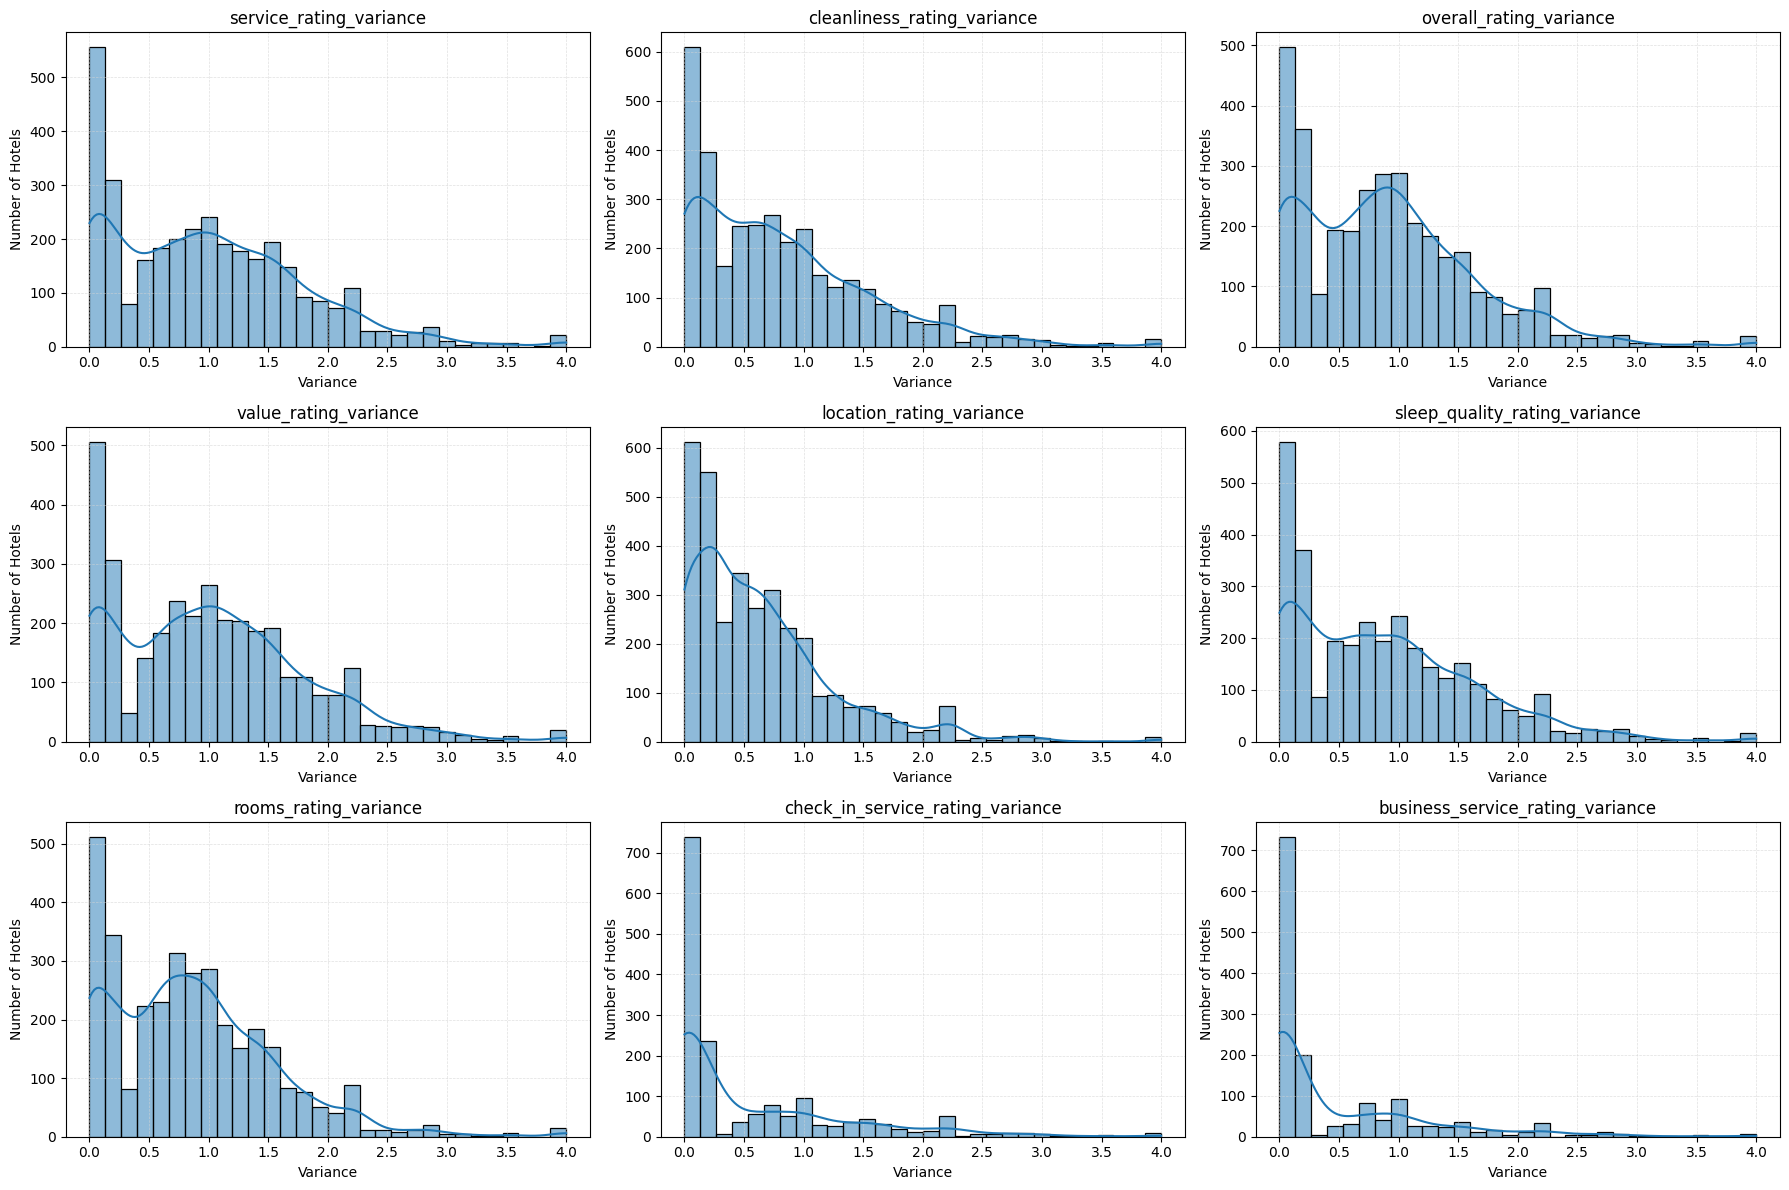

In [57]:
variance_cols = [col for col in hotels_df.columns if 'variance' in col]

num_cols = 3
num_rows = (len(variance_cols) + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows*4))
axes = axes.flatten()

for i, col in enumerate(variance_cols):
    sns.histplot(hotels_df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("Variance")
    axes[i].set_ylabel("Number of Hotels")
    axes[i].grid(True, color='lightgray', linestyle='--', linewidth=0.5, alpha=0.7)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

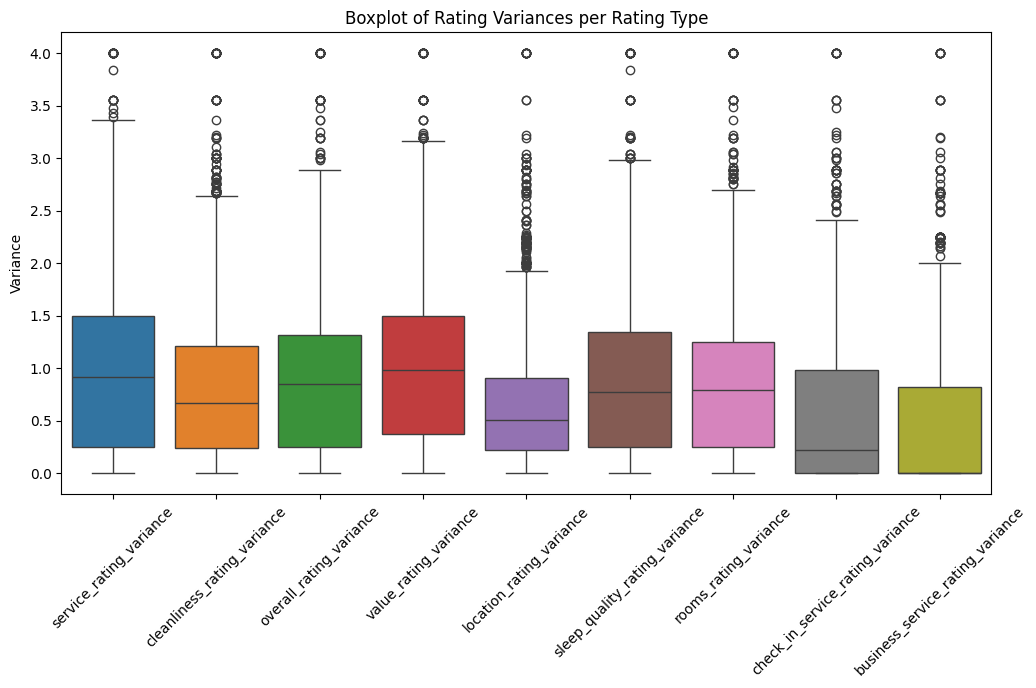

In [58]:
plt.figure(figsize=(12,6))
sns.boxplot(data=hotels_df[variance_cols])
plt.xticks(rotation=45)
plt.ylabel("Variance")
plt.title("Boxplot of Rating Variances per Rating Type")
plt.show()


---

## 4. Analytics by Business Questions

### **a. How does the hotel rating differ by location?**

ALERT!!! Location is not in the hotels_df

### **b. Best and worst hotels from each service category?**

In [59]:
# Generated by chatGPT but will be reviewed and modified in a few moment
def analyze_hotels_per_category_subplots(df, min_reviews=1):

    df_filtered = df[df['num_reviews'] >= min_reviews].copy()
    
    rating_cols = [c for c in df.columns if c.startswith('avg_') and 'rating' in c]
    
    n_cols = 2  # number of columns in subplot grid
    n_rows = (len(rating_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows*4))
    axes = axes.flatten()
    
    for i, col in enumerate(rating_cols):
        var_col = col.replace('avg_', '') + '_variance'
        if var_col not in df_filtered.columns:
            df_filtered[var_col] = 0
        
        # Sort and pick top 3 + bottom 3
        df_sorted = df_filtered.sort_values(
            by=[col, 'num_reviews', var_col],
            ascending=[False, False, True]
        )
        best_3 = df_sorted.head(3)
        worst_3 = df_sorted.tail(3)
        combined = pd.concat([best_3, worst_3])
        
        # X labels: hotel_id (num_reviews)
        x_labels = [f"{hid}\n({rev})" for hid, rev in zip(combined['hotel_id'], combined['num_reviews'])]
        
        combined['hue'] = ['Best']*3 + ['Worst']*3
        
        sns.barplot(
            x=x_labels,
            y=combined[col].values,
            hue=combined['hue'],        # assign hue
            dodge=False,                 # prevents side-by-side bars
            palette={'Best': 'green', 'Worst': 'red'},
            ax=axes[i]
        )
        axes[i].legend_.remove()
        
        axes[i].set_title(f"{col}")
        axes[i].set_ylabel("Rating")
        axes[i].set_xlabel("Hotel ID (num_reviews)")
        axes[i].grid(True, color='lightgray', linestyle='--', linewidth=0.5, alpha=0.7)
    
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)  # adjust to make space for suptitle
    plt.suptitle("Best & Worst performer by each category", fontsize=16)
    plt.show()


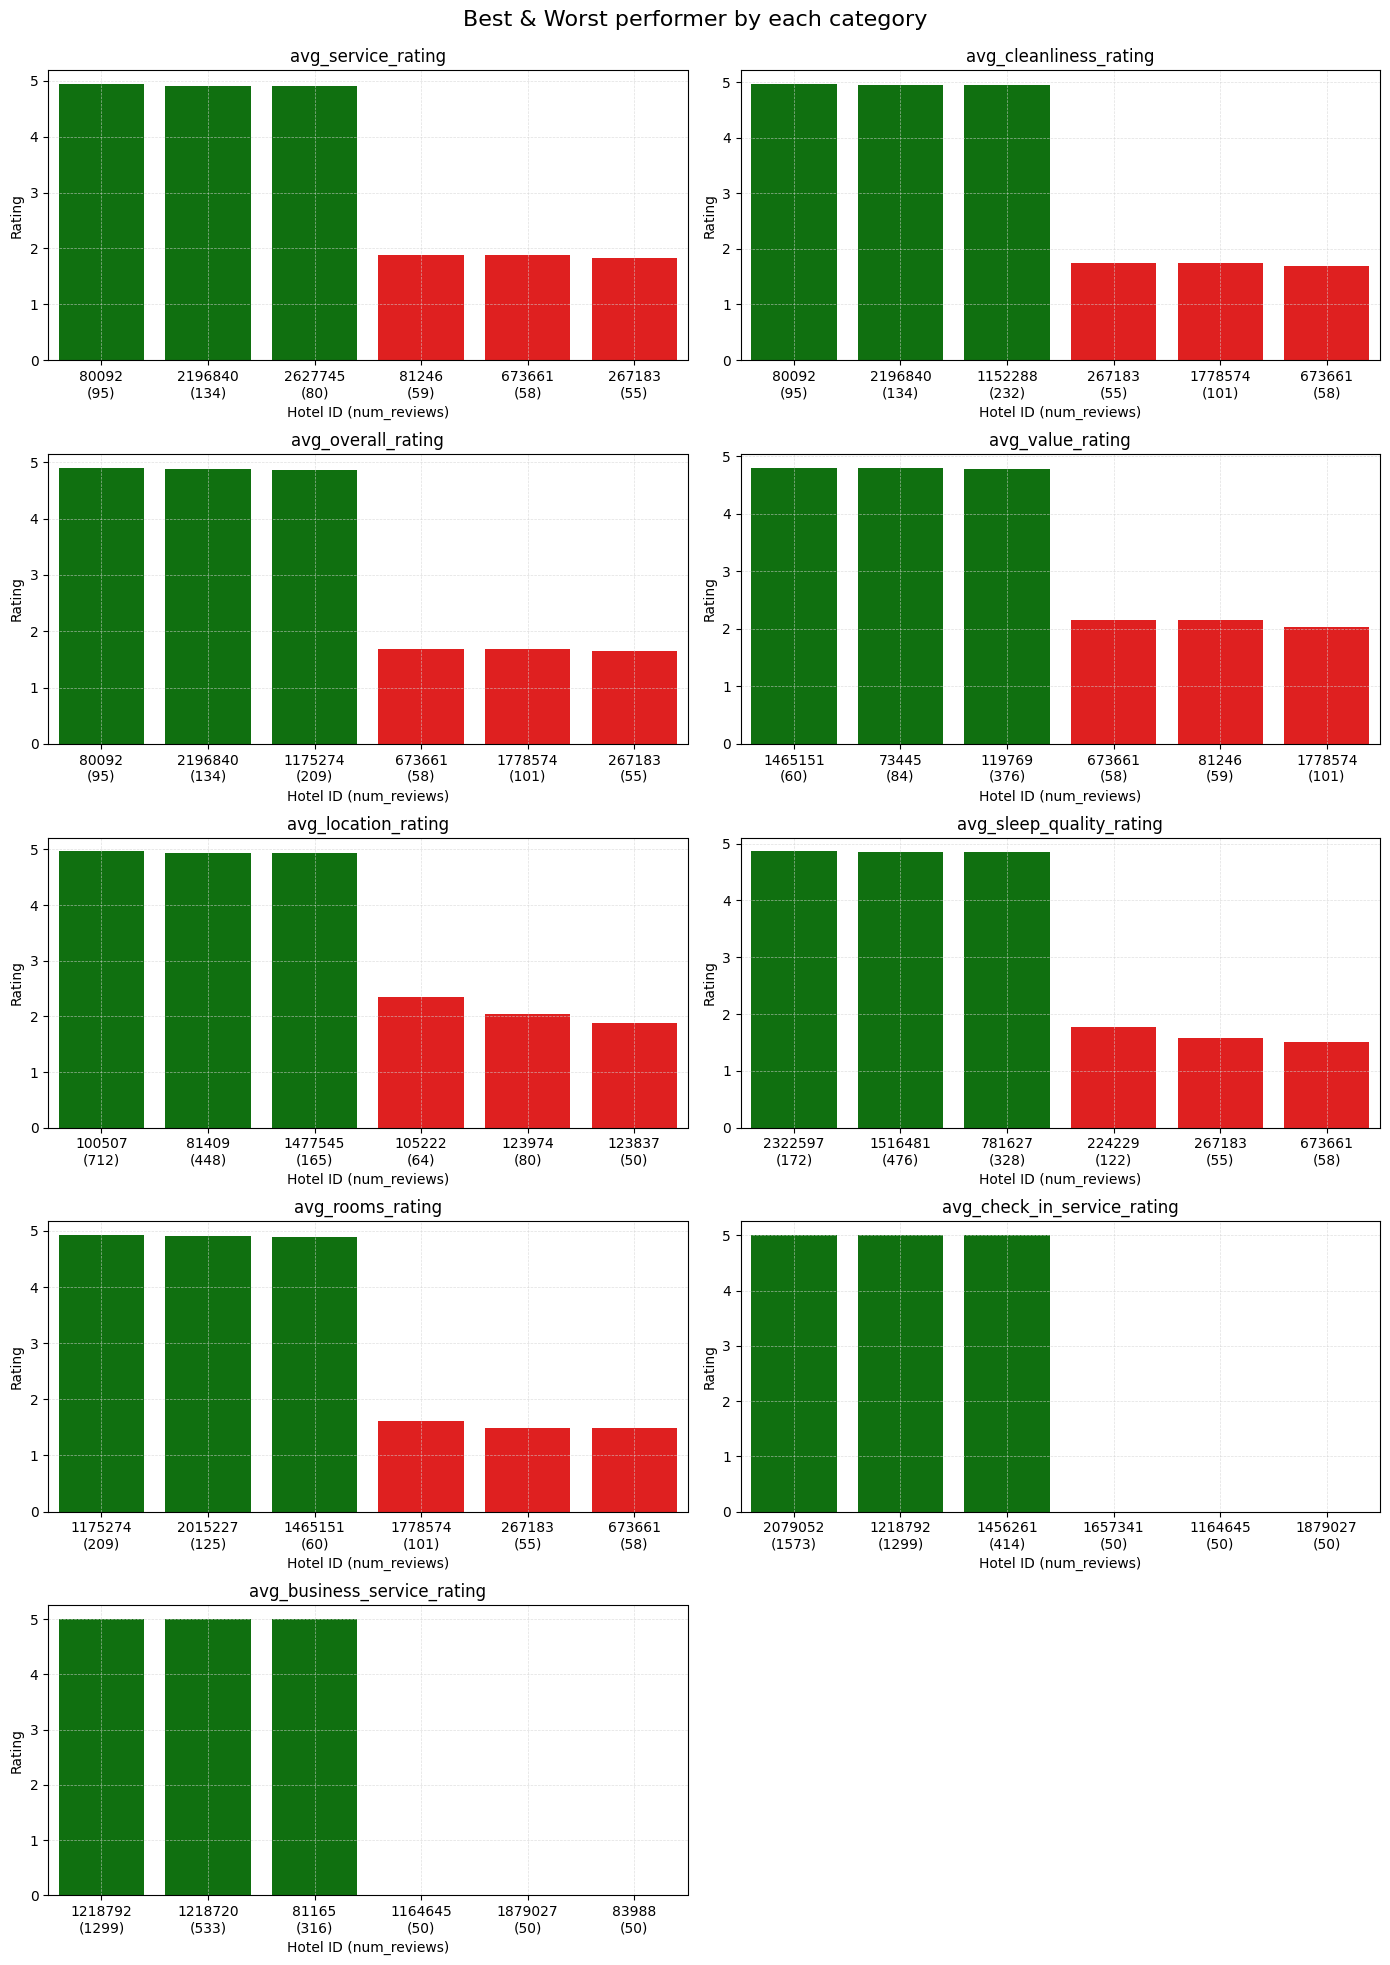

In [60]:
analyze_hotels_per_category_subplots(hotels_df, min_reviews=50)

### **c. Repeating visitor? mobile vs non mobile? fast and late review (3 mos threshold)?**

### **d. Best compliment Keyword for each hotels?**

My idea is to normalize the reviews, and check using tf-idf

In [61]:
reviews_df.head(2)

,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id,date_stayed_dt,reviews_days_since_stay
0,“Daaaaaa Bears!”,I recently stayed at W Chicago Lakeshore and o...,2012-11-01,225108,0,2012-11-19,145753174,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,714F49AC057498AEA304343E569A2A03,2012-11-01,18 days
1,“Would go back in a heartbeat- Location Locati...,We booked this hotel after out initial travel ...,2010-09-01,122005,1,2010-10-02,81870377,0,3.0,5.0,4.0,5.0,5.0,5.0,3.0,NaN,NaN,74C5A4455E1AAE46B0C54FC6CCBD7033,2010-09-01,31 days


In [62]:
# Constants
PUNCTUATION = """!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~“”‘’"""
TOP_K_KEYWORDS = 10 # top k number of keywords to retrieve in a ranked document
STOPWORD_PATH = "../src/stopwords.txt"
# PAPERS_PATH = "/kaggle/input/nips-papers-1987-2019-updated/papers.csv"

In [63]:
keyword_df = reviews_df.copy()
keyword_df = keyword_df[['hotel_id', 'title', 'text']]

In [64]:
from utils import (
    clean_text,
    get_stopwords_list,
    get_keywords,
)

keyword_df['title'] = keyword_df['title'].apply(lambda x: clean_text(x, punctuation=PUNCTUATION))
keyword_df['text'] = keyword_df['text'].apply(lambda x: clean_text(x, punctuation=PUNCTUATION))

In [65]:
keyword_df

,hotel_id,title,text
0,225108,daaaaaa bears,i recently stayed at w chicago lakeshore and o...
1,122005,would go back in a heartbeat location location...,we booked this hotel after out initial travel ...
2,939375,clean friendly affordable alternative to downtown,i am currently here in the hotel checking out ...
3,87573,atrium pool location and basic amenities were ...,two 10 yr olds enjoyed the large pool in the a...
4,123022,very good but nothing spectacular,stayed here on business because it was within ...
...,...,...,...
79995,1486034,oops not the best choice for me,the w boston should have been better for me bu...
79996,112412,my favorite hotel in seattle,the alexis is the best the service is always g...
79997,115644,good but to hot,this hotel needs aircon the rooms are to warm ...
79998,1549134,everything you would expect from a 4 star prop...,i had a late evening flight into houstons hobb...


In [66]:
corpora_title = keyword_df['title'].to_list()
corpora_text = keyword_df['text'].to_list()

combined_corpora = [
    f"{title} {text}"
    for title, text in zip(corpora_title, corpora_text)
]
combined_corpora[:5]

['daaaaaa bears i recently stayed at w chicago lakeshore and once again was impressted at how the staff went above and beyond to ensure i was well taken care of the location is fantastic and if youre lucky enough to get a lake view its even better we were in town for the bears texans games and having an amazing place to hang our hat made the trip that much easier i will stay there again and hopefully georgia is still working there shes awesome',
 'would go back in a heartbeat location location location and true ny style we booked this hotel after out initial travel plans to stay at another nyc hotel fell through and were we glad they did if you want a location that has everything on your doorstep creating the true in the movies feel then this is the hotel for you with madison sqaure garden on the same crossroads as the hotel and macys and the empire state building oe the same street just one block away you couldnt ask for better 10 minutes walk in the other direction will bring you to 

In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer

#load a set of stop words
stopwords=get_stopwords_list(STOPWORD_PATH)

# Initializing TF-IDF Vectorizer with stopwords
vectorizer = TfidfVectorizer(stop_words=stopwords, smooth_idf=True, use_idf=True)

# Creating vocab with our corpora
# Exlcluding first 10 docs for testing purpose
vectorizer.fit_transform(combined_corpora)

# Storing vocab
feature_names = vectorizer.get_feature_names_out()

/Users/nadia/Documents/IS5126 Hands-on with Applied Analytics/Assignment/IS512-Hotel-Analytics/venv/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['come', 'vis', 'viser', 'visest'] not in stop_words.
  warnings.warn(


In [68]:
result = []
for doc in combined_corpora:
    df = {}
    df['full_text'] = doc
    df['top_keywords'] = get_keywords(vectorizer, feature_names, doc, top_k_keywords=TOP_K_KEYWORDS)
    result.append(df)
    
final = pd.DataFrame(result)
final

,full_text,top_keywords
0,daaaaaa bears i recently stayed at w chicago l...,"[bears, impressted, daaaaaa, texans, georgia, ..."
1,would go back in a heartbeat location location...,"[effect, yorker, want, english, just, oe, harl..."
2,clean friendly affordable alternative to downt...,"[enjoyed, alternative, friendlyexcept, crinkel..."
3,atrium pool location and basic amenities were ...,"[atrium, pool, forms, olds, yr, beverage, plas..."
4,very good but nothing spectacular stayed here ...,"[taxi, ride, begins, 43, small, inclined, heav..."
...,...,...
79995,oops not the best choice for me the w boston s...,"[synthesize, mazelike, malloffice, wasnt, inde..."
79996,my favorite hotel in seattle the alexis is the...,"[alexis, seattle, favorite, awesome, visit, go..."
79997,good but to hot this hotel needs aircon the ro...,"[blockedthey, sleepthe, menuthe, retaurant, pa..."
79998,everything you would expect from a 4 star prop...,"[star, property, prepair, extream, lowball, ra..."


We got the keyword, although it's not 100% accurate

In [69]:
# Quiet mode
import os
import warnings
import logging

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message="n_jobs value.*", category=UserWarning)
warnings.filterwarnings("ignore", message="Glyph .* missing from font\\(s\\)", category=UserWarning)

logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("sentence_transformers").setLevel(logging.ERROR)
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

Number of unique words: 111820


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1528.35it/s, Materializing param=pooler.dense.weight]                             


(111820, 384)
(111820, 2)


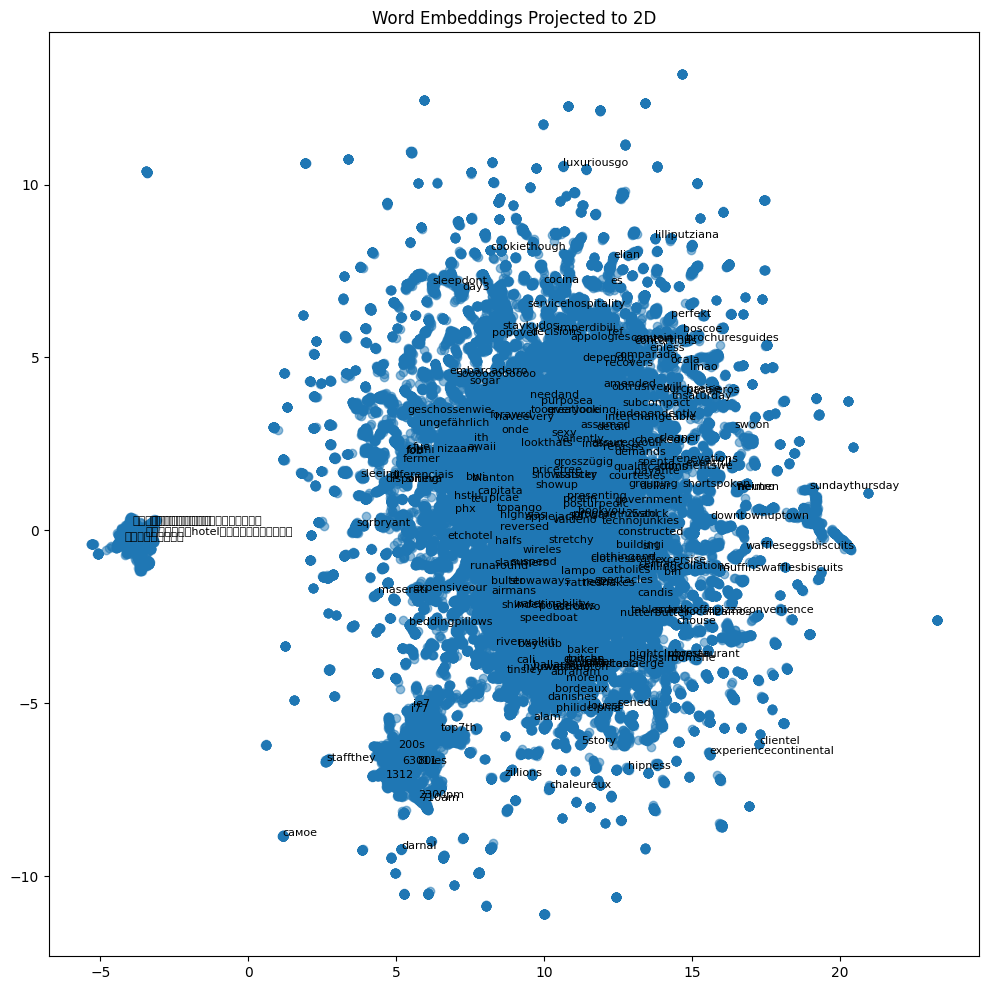

In [70]:
import itertools

# Flatten all top_keywords into one set
all_words = set(itertools.chain.from_iterable(final['top_keywords']))
print(f"Number of unique words: {len(all_words)}")

from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

# Get embeddings
word_list = list(all_words)
embeddings = model.encode(word_list)
print(embeddings.shape)  # (num_words, embedding_dim)

import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_components=2, random_state=42)
embeddings_2d = reducer.fit_transform(embeddings)

print(embeddings_2d.shape)  # (num_words, 2)

plt.figure(figsize=(12, 12))
plt.scatter(embeddings_2d[:,0], embeddings_2d[:,1], alpha=0.5)

# Optional: label top words (might get cluttered)
for i, word in enumerate(word_list[:200]):
    plt.text(embeddings_2d[i,0], embeddings_2d[i,1], word, fontsize=8)

plt.title("Word Embeddings Projected to 2D")
plt.show()


### **e. Which rating category contributes the most to the overall rating?**

check the correlation of the scores. this can help the hotel to decide where to invest next

### **f. Trend in the stars during the years for each hotel or for each location group**

### **g. "How does my hotel perform?"**

by inputting the average rating of the current hotel, we can show graph like "you perform better than 90% of hotels worldwide, and 95% in the same region".

### **h. top 5 hotel and bottom 5 hotel per location**

### **i. best and worst service per location to tell which countries are better in certain category**

### **j. does mobile reviews is shorter and less helpful?**

### **k. Do fast reviews tend to be more negative?**

### **l. are experienced travelers more critical than casual reviewers?**

---

Column Explanation:
* title
* text
* date_stayed
* hotel_id
* num_helpful_votes
* review_date
* review_id
* via_mobile
* service_rating
* cleanliness_rating
* overall_rating
* value_rating
* location_rating
* sleep_quality_rating
* rooms_rating
* check_in_service_rating
* business_service_rating
* author_key

### Close connection

In [71]:
conn.close()

Issue:
- is the location denotes the hotel's location or the user
- where is the complete dataset .db
- data validation step is still incomplete (date checking and else)
- column description step is missing yet essential for us to make
- feature engineering part needs more ideas